# بناء النوذج للتعلم الالي 

# (1)تجهيز البيانات لتدريب النموذج

In [174]:
import numpy as np  # مكتبة التحليل الأولي لعمليات الرياضيات والإحصاء
import pandas as pd  # مكتبة التحليل الثانوي لتحليل ومعالجة البيانات
import matplotlib.pyplot as plt  # مكتبة التحليل الثانوي لإنشاء الرسوم البيانية
import seaborn as sns  # مكتبة التحليل الثانوي لإنشاء الرسوم البيانية المتقدمة
import sklearn#للتقسيم
import statsmodels
import tensorflow as tf
import torch
from scipy.stats import chi2_contingency

from tabulate import tabulate
from textblob import TextBlob#لتعلم النصوص ولن احتاجها هنا
import numexpr as ne

#خاصة بهذا القسم


# استيراد مكتبة TensorFlow
import tensorflow as tf

# استيراد مكتبة Keras
import keras

# استيراد مكتبة PyTorch
import torch

# استيراد مكتبة Scikit-learn
import sklearn



In [175]:

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')


# خطوات بناء النموذج

# مرحلة التجهيز

# (1)تجهيز البيانات  تحويل القيم النصية الى  رقمية

# من جدول  تحويل بيانات  KidneyPatientsيوسف Gender ذكر=1وأنثى =0

In [78]:


# تحويل القيم النصية في عمود Gender إلى القيم الرقمية
data['Gender'].replace({'أنثى': 0, 'ذكر': 1}, inplace=True)

In [79]:

# تحويل القيم النصية في عمود DateOfDeath إلى القيم الرقمية
data['DateOfDeath'].replace({'no': 0, 'yes': 1}, inplace=True)

In [80]:

# تحويل القيم النصية في عمود nazeh إلى القيم الرقمية
data['nazeh'].replace({'no': 0,'yas':1}, inplace=True)

In [81]:

# حساب عدد الظهور لكل قيمة في العمود nazeh
counts = data['nazeh'].value_counts()

# ترتيب النتائج تنازلياً
sorted_counts = counts.sort_values(ascending=False)

# طباعة  النتائج
print(sorted_counts.index.tolist())

[0, 1]


# معالجة عمودي المديرية والمحافظة

In [82]:

# حساب عدد الظهور لكل قيمة في العمود Directorate
counts = data['Directorate'].value_counts()

# ترتيب النتائج تنازلياً
sorted_counts = counts.sort_values(ascending=False)

# طباعة أسماء المديريات المرتبة تنازلياً حسب الأكثر تكراراً
print(sorted_counts.index.tolist())

['بعدان', 'العدين', 'تعز', 'السياني', 'إب', 'حبيش', 'ماوية', 'التعزية', 'جبلة', 'القاعدة', 'الظهار', 'المشنة', 'المخادر', 'القفر', 'ذي السفال', 'المجعارة', 'شرعب', 'الحوبان', 'السبرة', 'مذيخرة', 'شرعب السلام', 'مقبنة', 'الحشا', 'زبيد', 'الحزم', 'شرعب الرونة', 'فرع العدين', 'جبل راس', 'الحديدة', 'الضالع', 'المسيلة', 'القبيطة', 'خدير', 'السحول', 'ميتم', 'الجعاشن', 'العود', 'الجراحي', 'الفرع', 'صبر', 'يريم', 'دمنة خدير', 'حزم العدين', 'وراف', 'الراهدة', 'قعطبة', 'السبل', 'عتمة', 'القاهرة', 'صالة', 'الحالي', 'الرضمة', 'سامع', 'الشعر', 'الدمنة', 'مفرق حبيش', 'السدة', 'شمير', 'الربادي', 'مشورة', 'بيت الفقية', 'الحيمة', 'الجند', 'حيفان', 'سمارة', 'الرونة', 'الدليل', 'يافع', 'دمت', 'الصلبة', 'النادرة', 'المحافظة', 'مظفر', 'هجدة', 'النجد الأحمر', 'الميناء', 'صهبان', 'شارع تعز', 'جرافة', 'المحشار', 'المحويت', 'قدس', 'ذمنة', 'مفرق شرعب', 'قبيطة', 'تهامة', 'الراجحي', 'المحابشة', 'ريمان', 'قحزة', 'المخا', 'الحصين', 'شعب يافع', 'الربيعي', 'ذمنة خليل', 'المعاين', 'كتاب', 'منزل الراعي اب', 'سارة', 'ال

In [83]:

# حساب عدد الظهور لكل قيمة في العمود Governorate
counts = data['Governorate'].value_counts()

# ترتيب النتائج تنازلياً
sorted_counts = counts.sort_values(ascending=False)

# طباعة أسماء المحافظات المرتبة تنازلياً حسب الأكثر تكراراً
print(sorted_counts.index.tolist())

['إب', 'تعز', 'الحديدة', 'الضالع', 'ذمار', 'لحج', 'المحويت', 'عدن', 'حجة', 'البيضاء', 'أبين', 'عمران']


In [84]:

# حساب عدد الظهور لكل قيمة في العمود Directorate
counts = data['Directorate'].value_counts()

# ترتيب النتائج تنازلياً
sorted_counts = counts.sort_values(ascending=False)

# طباعة أسماء المديريات المرتبة تنازلياً مع رقمها في القائمة
for i, directorate in enumerate(sorted_counts.index.tolist()):
    print(f"{i+1}: {directorate}")

1: بعدان
2: العدين
3: تعز
4: السياني
5: إب
6: حبيش
7: ماوية
8: التعزية
9: جبلة
10: القاعدة
11: الظهار
12: المشنة
13: المخادر
14: القفر
15: ذي السفال
16: المجعارة
17: شرعب
18: الحوبان
19: السبرة
20: مذيخرة
21: شرعب السلام
22: مقبنة
23: الحشا
24: زبيد
25: الحزم
26: شرعب الرونة
27: فرع العدين
28: جبل راس
29: الحديدة
30: الضالع
31: المسيلة
32: القبيطة
33: خدير
34: السحول
35: ميتم
36: الجعاشن
37: العود
38: الجراحي
39: الفرع
40: صبر
41: يريم
42: دمنة خدير
43: حزم العدين
44: وراف
45: الراهدة
46: قعطبة
47: السبل
48: عتمة
49: القاهرة
50: صالة
51: الحالي
52: الرضمة
53: سامع
54: الشعر
55: الدمنة
56: مفرق حبيش
57: السدة
58: شمير
59: الربادي
60: مشورة
61: بيت الفقية
62: الحيمة
63: الجند
64: حيفان
65: سمارة
66: الرونة
67: الدليل
68: يافع
69: دمت
70: الصلبة
71: النادرة
72: المحافظة
73: مظفر
74: هجدة
75: النجد الأحمر
76: الميناء
77: صهبان
78: شارع تعز
79: جرافة
80: المحشار
81: المحويت
82: قدس
83: ذمنة
84: مفرق شرعب
85: قبيطة
86: تهامة
87: الراجحي
88: المحابشة
89: ريمان
90: قحزة
91: المخا
92: الحصين
93

In [85]:

# حساب عدد الظهور لكل قيمة في العمود Directorate
counts = data['Directorate'].value_counts()

# ترتيب النتائج تنازليًا
sorted_counts = counts.sort_values(ascending=False)

# تحويل اسم المديريات إلى الرقم المتوافق مع موقعها في الترتيب
ranked_directorates = sorted_counts.rank(ascending=False)

# طباعة الأرقام والمديريات المرتبة تنازليًا
print("النتائج:")
for i, directorate in enumerate(sorted_counts.index.tolist()):
    rank = int(ranked_directorates[directorate])
    print(f"{rank}: {directorate}")

# تحويل اسم المديرية إلى رقم المديرية المتوافق مع موقعها في الترتيب
def get_directorate_rank(directorate):
    return int(ranked_directorates[directorate])

# تحويل جميع المديريات إلى أرقام
directorate_ranks = {}
for directorate in sorted_counts.index.tolist():
    rank = get_directorate_rank(directorate)
    directorate_ranks[directorate] = rank

# طباعة جميع المديريات مع أرقامها
print("\nكل المديريات مع أرقامها:")
print(directorate_ranks)

النتائج:
1: بعدان
2: العدين
2: تعز
4: السياني
5: إب
6: حبيش
7: ماوية
8: التعزية
9: جبلة
10: القاعدة
11: الظهار
12: المشنة
13: المخادر
14: القفر
15: ذي السفال
16: المجعارة
17: شرعب
18: الحوبان
19: السبرة
20: مذيخرة
21: شرعب السلام
22: مقبنة
23: الحشا
24: زبيد
25: الحزم
25: شرعب الرونة
27: فرع العدين
27: جبل راس
29: الحديدة
29: الضالع
31: المسيلة
32: القبيطة
32: خدير
34: السحول
36: ميتم
36: الجعاشن
36: العود
38: الجراحي
39: الفرع
40: صبر
41: يريم
42: دمنة خدير
43: حزم العدين
43: وراف
45: الراهدة
45: قعطبة
47: السبل
49: عتمة
49: القاهرة
49: صالة
51: الحالي
53: الرضمة
53: سامع
53: الشعر
56: الدمنة
56: مفرق حبيش
56: السدة
56: شمير
59: الربادي
59: مشورة
62: بيت الفقية
62: الحيمة
62: الجند
66: حيفان
66: سمارة
66: الرونة
66: الدليل
66: يافع
70: دمت
70: الصلبة
70: النادرة
75: المحافظة
75: مظفر
75: هجدة
75: النجد الأحمر
75: الميناء
75: صهبان
75: شارع تعز
87: جرافة
87: المحشار
87: المحويت
87: قدس
87: ذمنة
87: مفرق شرعب
87: قبيطة
87: تهامة
87: الراجحي
87: المحابشة
87: ريمان
87: قحزة
87: المخا
87: 

In [86]:

# تحويل اسماء المديريات إلى أرقام توافقية مع ترتيبها في الجدول
def get_directorate_rank(directorate):
    counts = data['Directorate'].value_counts()
    sorted_counts = counts.sort_values(ascending=False)
    ranked_directorates = sorted_counts.rank(ascending=False)
    return int(ranked_directorates[directorate])

data['Directorate'] = data['Directorate'].apply(get_directorate_rank)

# تغيير اسم العمود "Directorate" إلى "Directorate Rank"
data = data.rename(columns={'Directorate': 'Directorate'})

# طباعة الجدول
print(data)

      Gender  TheAge  Directorate Governorate BloodType VirusType   
0          1      50            2          إب        a+       neg  \
1          1      42            1          إب        o+       neg   
2          0      50            9          إب        a+       neg   
3          1      74            6          إب        o+       neg   
4          1      50            9          إب        a+       neg   
...      ...     ...          ...         ...       ...       ...   
3823       1      47          181         تعز        a+       neg   
3824       1      47          181         تعز        a+       neg   
3825       0      47          181     الحديدة        o+       neg   
3826       0      47          181       عمران        o+       neg   
3827       0      47          181         تعز        o+       neg   

      TheDateTheFirstWash Sickyear  DateOfDeath  nazeh  Number  
0                    2017     2017            0      0       1  
1                    2017     2017       

# عمود المحافظة

In [87]:

# حساب عدد الظهور لكل قيمة في العمود Governorate
counts = data['Governorate'].value_counts()

# ترتيب النتائج تنازليًا
sorted_counts = counts.sort_values(ascending=False)

# تحويل اسم المحافظات إلى الرقم المتوافق مع موقعها في الترتيب
ranked_directorates = sorted_counts.rank(ascending=False)

# طباعة الأرقام والمحافظات المرتبة تنازليًا
print("النتائج:")
for i, directorate in enumerate(sorted_counts.index.tolist()):
    rank = int(ranked_directorates[directorate])
    print(f"{rank}: {directorate}")

# تحويل اسم المحافظة إلى رقم المحافظة المتوافق مع موقعها في الترتيب
def get_directorate_rank(directorate):
    return int(ranked_directorates[directorate])

# تحويل جميع المحافظات إلى أرقام
directorate_ranks = {}
for directorate in sorted_counts.index.tolist():
    rank = get_directorate_rank(directorate)
    directorate_ranks[directorate] = rank

# طباعة جميع المحافظات مع أرقامها
print("\nكل المحافظات مع أرقامها:")
print(directorate_ranks)

النتائج:
1: إب
2: تعز
3: الحديدة
4: الضالع
5: ذمار
6: لحج
7: المحويت
8: عدن
9: حجة
10: البيضاء
11: أبين
11: عمران

كل المحافظات مع أرقامها:
{'إب': 1, 'تعز': 2, 'الحديدة': 3, 'الضالع': 4, 'ذمار': 5, 'لحج': 6, 'المحويت': 7, 'عدن': 8, 'حجة': 9, 'البيضاء': 10, 'أبين': 11, 'عمران': 11}


In [88]:

# حساب عدد الظهور لكل قيمة في العمود Governorate
counts = data['Governorate'].value_counts()

# ترتيب النتائج تنازلياً
sorted_counts = counts.sort_values(ascending=False)

# طباعة أسماء المحافظات المرتبة تنازلياً مع رقمها في القائمة
for i, directorate in enumerate(sorted_counts.index.tolist()):
    print(f"{i+1}: {directorate}")

1: إب
2: تعز
3: الحديدة
4: الضالع
5: ذمار
6: لحج
7: المحويت
8: عدن
9: حجة
10: البيضاء
11: أبين
12: عمران


In [89]:

# تحويل اسماء المحافظات إلى أرقام توافقية مع ترتيبها في الجدول
def get_directorate_rank(directorate):
    counts = data['Governorate'].value_counts()
    sorted_counts = counts.sort_values(ascending=False)
    ranked_directorates = sorted_counts.rank(ascending=False)
    return int(ranked_directorates[directorate])

data['Governorate'] = data['Governorate'].apply(get_directorate_rank)

# تغيير اسم العمود "Governorate" إلى "Governorate Rank"
data = data.rename(columns={'Governorate': 'Governorate'})

# طباعة الجدول
print(data)

      Gender  TheAge  Directorate  Governorate BloodType VirusType   
0          1      50            2            1        a+       neg  \
1          1      42            1            1        o+       neg   
2          0      50            9            1        a+       neg   
3          1      74            6            1        o+       neg   
4          1      50            9            1        a+       neg   
...      ...     ...          ...          ...       ...       ...   
3823       1      47          181            2        a+       neg   
3824       1      47          181            2        a+       neg   
3825       0      47          181            3        o+       neg   
3826       0      47          181           11        o+       neg   
3827       0      47          181            2        o+       neg   

      TheDateTheFirstWash Sickyear  DateOfDeath  nazeh  Number  
0                    2017     2017            0      0       1  
1                    2017    

# معالجة عمودي فصائل الدم ونوع فيروس الكبد

In [90]:

# احتساب التكرارات لعمود BloodType وترتيبها تنازليًا
blood_counts = data['BloodType'].value_counts().sort_values(ascending=False)

# طباعة النتائج
print(blood_counts.head())

BloodType
o+     2494
a+      874
o-      136
b+      135
ab+     131
Name: count, dtype: int64


In [91]:


# استخراج القيم المختلفة في العمود BloodType وتحويلها إلى قائمة
blood_types = data['BloodType'].unique().tolist()

# طباعة النتائج
print(blood_types)

['a+', 'o+', 'a-', 'ab+', 'o-', 'b+', 'b-']


In [92]:


# احتساب التكرارات لعمود BloodType وترتيبها تنازليًا
blood_counts = data['BloodType'].value_counts().sort_values(ascending=False)

# طباعة النتائج
print(blood_counts)

BloodType
o+     2494
a+      874
o-      136
b+      135
ab+     131
a-       45
b-       13
Name: count, dtype: int64


In [93]:

# احتساب التكرارات لعمود BloodType وترتيبها تنازليًا
blood_counts = data['BloodType'].value_counts().sort_values(ascending=False)

# ترقيم النتائج بترتيب الترتيب النازل
blood_rank = blood_counts.rank(ascending=False).astype(int)

# طباعة النتائج
print(blood_rank)

BloodType
o+     1
a+     2
o-     3
b+     4
ab+    5
a-     6
b-     7
Name: count, dtype: int32


In [94]:

# احتساب التكرارات لعمود BloodType وترتيبها تنازليًا
BloodType_counts = data['BloodType'].value_counts().sort_values(ascending=False)

# ترقيم النتائج بترتيب الترتيب النازل
BloodType_rank = blood_counts.rank(ascending=False).astype(int)

# تعيين الأرقام المطلوبة لكل قيمة
blood_map = {'o+': 1, 'a+': 2, 'o-': 3, 'b+': 4, 'ab+': 5, 'a-': 6, 'b-': 7}
blood_rank = blood_rank.replace(blood_map)

# طباعة النتائج
print(blood_rank)

BloodType
o+     1
a+     2
o-     3
b+     4
ab+    5
a-     6
b-     7
Name: count, dtype: int32


In [95]:

# تحويل أنواع فصائل الدم إلى أرقام توافقية مع ترتيبها في الجدول
def get_directorate_rank(directorate):
    counts = data['BloodType'].value_counts()
    sorted_counts = counts.sort_values(ascending=False)
    ranked_directorates = sorted_counts.rank(ascending=False)
    return int(ranked_directorates[directorate])

data['BloodType'] = data['BloodType'].apply(get_directorate_rank)

# تغيير اسم العمود "BloodType" إلى "BloodType Rank"
data = data.rename(columns={'BloodType': 'BloodType'})

# طباعة الجدول
print(data)

      Gender  TheAge  Directorate  Governorate  BloodType VirusType   
0          1      50            2            1          2       neg  \
1          1      42            1            1          1       neg   
2          0      50            9            1          2       neg   
3          1      74            6            1          1       neg   
4          1      50            9            1          2       neg   
...      ...     ...          ...          ...        ...       ...   
3823       1      47          181            2          2       neg   
3824       1      47          181            2          2       neg   
3825       0      47          181            3          1       neg   
3826       0      47          181           11          1       neg   
3827       0      47          181            2          1       neg   

      TheDateTheFirstWash Sickyear  DateOfDeath  nazeh  Number  
0                    2017     2017            0      0       1  
1                

# نوع فيروس الكبد

In [96]:

# احتساب التكرارات لعمود VirusType وترتيبها تنازليًا
VirusType_counts = data['VirusType'].value_counts().sort_values(ascending=False)

# ترقيم النتائج بترتيب الترتيب النازل
VirusType_rank =VirusType_counts.rank(ascending=False).astype(int)

# طباعة النتائج
print(VirusType_rank)

VirusType
neg    1
c      2
b      3
c+b    4
Name: count, dtype: int32


In [97]:

# احتساب التكرارات لعمود VirusType وترتيبها تنازليًا
VirusType_counts = data['VirusType'].value_counts().sort_values(ascending=False)

# ترقيم النتائج بترتيب الترتيب النازل
VirusType_rank = VirusType_counts.rank(ascending=False).astype(int)

# تعيين الأرقام المطلوبة لكل قيمة
VirusType_map = {'neg': 1, 'c': 2,'b':3, 'c+b': 4}
VirusType_rank = VirusType_rank.replace(blood_map)

# طباعة النتائج
print(VirusType_rank)

VirusType
neg    1
c      2
b      3
c+b    4
Name: count, dtype: int32


In [98]:

# تحويل نوع الفيروس إلى أرقام توافقية مع ترتيبها في الجدول
def get_directorate_rank(directorate):
    counts = data['VirusType'].value_counts()
    sorted_counts = counts.sort_values(ascending=False)
    ranked_directorates = sorted_counts.rank(ascending=False)
    return int(ranked_directorates[directorate])

data['VirusType'] = data['VirusType'].apply(get_directorate_rank)

# تغيير اسم العمود "VirusType" إلى "VirusType Rank"
data = data.rename(columns={'VirusType': 'VirusType'})

# طباعة الجدول
print(data)

      Gender  TheAge  Directorate  Governorate  BloodType  VirusType   
0          1      50            2            1          2          1  \
1          1      42            1            1          1          1   
2          0      50            9            1          2          1   
3          1      74            6            1          1          1   
4          1      50            9            1          2          1   
...      ...     ...          ...          ...        ...        ...   
3823       1      47          181            2          2          1   
3824       1      47          181            2          2          1   
3825       0      47          181            3          1          1   
3826       0      47          181           11          1          1   
3827       0      47          181            2          1          1   

      TheDateTheFirstWash Sickyear  DateOfDeath  nazeh  Number  
0                    2017     2017            0      0       1  
1    

# معالجة عمود السنة المرضية

In [99]:

# احتساب التكرارات لعمود Sickyear وترتيبها تنازليًا
Sickyear_counts = data['Sickyear'].value_counts().sort_values(ascending=False)

# ترقيم النتائج بترتيب الترتيب النازل
Sickyear_rank =Sickyear_counts.rank(ascending=False).astype(int)

# طباعة النتائج
print(Sickyear_rank)

Sickyear
2018     1
2017     2
2019     3
2020     4
2021     5
2022     6
2018-    7
2019-    8
2023     9
Name: count, dtype: int32


In [100]:

# احتساب التكرارات لعمود Sickyear وترتيبها تنازليًا
VirusType_counts = data['Sickyear'].value_counts().sort_values(ascending=False)

# ترقيم النتائج بترتيب الترتيب النازل
Sickyear_rank = Sickyear_counts.rank(ascending=False).astype(int)

# تعيين الأرقام المطلوبة لكل قيمة
Sickyear_map = {'2018': 1, '2017': 2, '2019': 3, '2020': 4, '2021': 5, '2022': 6, '2018-': 7, '2019-':8 , '2023':9}
Sickyear_rank = Sickyear_rank.replace(blood_map)

# طباعة النتائج
print(Sickyear_rank)

Sickyear
2018     1
2017     2
2019     3
2020     4
2021     5
2022     6
2018-    7
2019-    8
2023     9
Name: count, dtype: int32


In [101]:

# تحويل السنوات إلى أرقام توافقية مع ترتيبها في الجدول
def get_directorate_rank(directorate):
    counts = data['Sickyear'].value_counts()
    sorted_counts = counts.sort_values(ascending=False)
    ranked_directorates = sorted_counts.rank(ascending=False)
    return int(ranked_directorates[directorate])

data['Sickyear'] = data['Sickyear'].apply(get_directorate_rank)

# تغيير اسم العمود "Sickyear" إلى "Sickyear Rank"
data = data.rename(columns={'Sickyear': 'Sickyear'})

# طباعة الجدول
print(data)

      Gender  TheAge  Directorate  Governorate  BloodType  VirusType   
0          1      50            2            1          2          1  \
1          1      42            1            1          1          1   
2          0      50            9            1          2          1   
3          1      74            6            1          1          1   
4          1      50            9            1          2          1   
...      ...     ...          ...          ...        ...        ...   
3823       1      47          181            2          2          1   
3824       1      47          181            2          2          1   
3825       0      47          181            3          1          1   
3826       0      47          181           11          1          1   
3827       0      47          181            2          1          1   

      TheDateTheFirstWash  Sickyear  DateOfDeath  nazeh  Number  
0                    2017         2            0      0       1  
1  

# معالجة تاريخ أول غسلة 

In [102]:

# حساب عدد التكرارات لكل اسم في عمود "TheDateTheFirstWash"
#dir_counts = data['TheDateTheFirstWash'].value_counts()

# طباعة النتائج
#for dir_name, count in dir_counts.items():
   # print(dir_name, count)

# البيانات بعدالمعالجة

In [103]:

# طباعة أسماء الأعمدة
print(data.columns)

# عرض ملخص للبيانات في الجدول
print(data.info())


# عرض DataFrame بعد ملء الخلايا الفارغة
print(data)

Index(['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType',
       'VirusType', 'TheDateTheFirstWash', 'Sickyear', 'DateOfDeath', 'nazeh',
       'Number'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3828 entries, 0 to 3827
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Gender               3828 non-null   int64
 1   TheAge               3828 non-null   int64
 2   Directorate          3828 non-null   int64
 3   Governorate          3828 non-null   int64
 4   BloodType            3828 non-null   int64
 5   VirusType            3828 non-null   int64
 6   TheDateTheFirstWash  3828 non-null   int64
 7   Sickyear             3828 non-null   int64
 8   DateOfDeath          3828 non-null   int64
 9   nazeh                3828 non-null   int64
 10  Number               3828 non-null   int64
dtypes: int64(11)
memory usage: 329.1 KB
None
      Gender  TheAge  Directorate 

In [927]:

# تحويل عمود "column_name" إلى أرقام بحسب ترتيبها في الجدول
#data['TheDateTheFirstWash'] = data['TheDateTheFirstWash'].rank(method='dense').astype(int)

# عرض البيانات المحدثة
#print(data)

In [104]:

# حفظ الجدول المدمج كملف CSV جديد
data.to_csv('KidneyPatientsGHadeer', encoding='utf-8-sig', index=False)


# حفظ DataFrame كملف CSV في القرص الصلب بترميز UTF-8
data.to_csv('E:\KidneyPatientsGHadeer', index=False, encoding='utf-8-sig')


In [105]:
# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer', encoding='utf-8')



#  كود بايثون يقوم بتحويل قيم عمود الى ارقام بحسب ترتيبها بالجدول اي  القيمة الاولى يجعلها = 1وهكذا حتى اخر قيمة يحولها لارقام 

#  كود يقوم بتقسيم البيانات الى مجموعة تدريب واختار وتحقق
ذا الكود يقوم بتقسيم البيانات على النحو التالي
اريد النتيجة تكون دقيقة حيث عدد الاعمدة =11 وعدد الصفوف =3828 صف
2683 من السجلات لمجموعة التدريب (70%)
572 لمجموعة الاختبار (15%)
573 لمجموعة التحقق (15%)
تم تهيئة random_state 


import pandas as pd
from sklearn.model_selection import train_test_split

In [929]:
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# لفصل الخاصيات والتسميات وتقسيم البيانات إلى مجموعات تدريب واختبار وتحقق. الكود يعتمد على استخدام دالة iloc من pandas لتحديد الخاصيات والتسميات
، ودالة train_test_split من مكتبة sklearn.model_selection لتقسيم البيانات.

في الفقرتين الأولى والثانية من الكود، تم استخدام نسبة تقسيم 70:15:15، حيث تم تقسيم البيانات إلى مجموعة تدريب ومجموعة اختبار ومجموعة تحقق. في 
        الفقرتين الثالثة والرابعة، تم استخدام نسبة تقسيم 70:20:10، حيث تم تقسيم البيانات إلى مجموعة تدريب ومجموعة اختبار ومجموعة تحقق.

الكود يبدو صحيحاً وسيقوم بتفيذ المهمة المطلوبة، ويمكن استخدامه لتقسيم البيانات إلى مجموعات تدريب واختبار وتحقق بنسب مختلف

In [1008]:

# فصل الخاصيات والتسميات 
X = data.iloc[:,:-1]  
y = data.iloc[:,-1]

# 70% تدريب - 15% اختبار - 15% تحقق
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.3, random_state=42)

# تقسيم مجموعة الاختبار
X_test, X_val, y_test, y_val = train_test_split(
   X_test, y_test, test_size=0.5,random_state=42) 

# تأكد من الأبعاد
print(X_train.shape, y_train.shape)  
# (2683, 11) (2683,)

print(X_test.shape, y_test.shape)
# (572, 11) (572,)   

print(X_val.shape, y_val.shape)
# (573, 11) (573,)


# 70% تدريب - 20% اختبار - 10% تحقق
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42)

# تقسيم مجموعة الاختبار 50٪ لتكون مجموعة التحقق  
X_test, X_val, y_test, y_val = train_test_split(
   X_test, y_test, test_size=0.5,random_state=42)


(2679, 10) (2679,)
(574, 10) (574,)
(575, 10) (575,)


# اختيار نموذج التعلم الآلي: 
 يمكن استخدام العديد من النماذج المختلفة مثل الشبكات العصبية الاصطناعية والتحليل الإحصائي وغيره

# الشبكة العصبية الاصطناعيةحيث أن الدقة للتنبؤ بالبيانات=1وهذا غير منطقي

In [106]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# تحويل البيانات إلى تسلسلات رقمية وتحويلها لتناسب النموذج
X = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash', 'nazeh', 'Number']]
y = data['Sickyear']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# بناء الشبكة العصبية الاصطناعية
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(9,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# تدريب الشبكة العصبية الاصطناعية
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100)

# تقييم أداء النموذج
model.evaluate(X_test, y_test)

# تصنيف بيانات جديدة
new_data = pd.DataFrame({'Gender': [0], 'TheAge': [50], 'Directorate': [1], 'Governorate': [1], 'BloodType': [0], 'VirusType': [2], 'TheDateTheFirstWash': [100], 'nazeh': [1], 'Number': [2]})
new_data = scaler.transform(new_data)
print(model.predict(new_data))

Epoch 1/100
96/96 [==============================] - 1s 1ms/step - loss: -8.9633 - accuracy: 0.3854
Epoch 2/100
96/96 [==============================] - 0s 1ms/step - loss: -97.6960 - accuracy: 0.4167
Epoch 3/100
96/96 [==============================] - 0s 2ms/step - loss: -470.5426 - accuracy: 0.4167
Epoch 4/100
96/96 [==============================] - 0s 2ms/step - loss: -1445.2721 - accuracy: 0.4167
Epoch 5/100
96/96 [==============================] - 0s 2ms/step - loss: -3281.8191 - accuracy: 0.4167
Epoch 6/100
96/96 [==============================] - 0s 1ms/step - loss: -6229.2456 - accuracy: 0.4167
Epoch 7/100
96/96 [==============================] - 0s 2ms/step - loss: -10493.3809 - accuracy: 0.4167
Epoch 8/100
96/96 [==============================] - 0s 2ms/step - loss: -16254.9521 - accuracy: 0.4167
Epoch 9/100
96/96 [==============================] - 0s 2ms/step - loss: -23728.2031 - accuracy: 0.4167
Epoch 10/100
96/96 [==============================] - 0s 2ms/step - loss: -3

In [110]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# تحويل البيانات إلى تسلسلات رقمية وتحويلها لتناسب النموذج
X = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash', 'nazeh', 'Number']]
y = data['Sickyear']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# بناء الشبكة العصبية الاصطناعية
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(9,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# تدريب الشبكة العصبية الاصطناعية
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100)

# تقييم أداء النموذج
model.evaluate(X_test, y_test)

# تصنيف بيانات جديدة
new_data = pd.DataFrame({'Gender': [0], 'TheAge': [50], 'Directorate': [1], 'Governorate': [1], 'BloodType': [0], 'VirusType': [2], 'TheDateTheFirstWash': [100], 'nazeh': [1], 'Number': [2]})
new_data = scaler.transform(new_data)
print(model.predict(new_data))

Epoch 1/100
96/96 [==============================] - 1s 1ms/step - loss: -8.6791 - accuracy: 0.3955
Epoch 2/100
96/96 [==============================] - 0s 2ms/step - loss: -114.5020 - accuracy: 0.4144
Epoch 3/100
96/96 [==============================] - 0s 1ms/step - loss: -578.6732 - accuracy: 0.4144
Epoch 4/100
96/96 [==============================] - 0s 2ms/step - loss: -1744.6599 - accuracy: 0.4144
Epoch 5/100
96/96 [==============================] - 0s 2ms/step - loss: -3941.7012 - accuracy: 0.4144
Epoch 6/100
96/96 [==============================] - 0s 2ms/step - loss: -7461.0054 - accuracy: 0.4144
Epoch 7/100
96/96 [==============================] - 0s 2ms/step - loss: -12463.8721 - accuracy: 0.4144
Epoch 8/100
96/96 [==============================] - 0s 2ms/step - loss: -19211.5059 - accuracy: 0.4144
Epoch 9/100
96/96 [==============================] - 0s 2ms/step - loss: -27908.7754 - accuracy: 0.4144
Epoch 10/100
96/96 [==============================] - 0s 2ms/step - loss: -

In [111]:
from sklearn.naive_bayes import GaussianNB

# فصل الميزات والهدف
X = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash','Sickyear', 'DateOfDeath', 'nazeh']]
y = data['Number']

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# تدريب النموذج
nb = GaussianNB()
nb.fit(X_train, y_train)

# تقييم النموذج
train_accuracy = nb.score(X_train, y_train)
test_accuracy = nb.score(X_test, y_test)
val_accuracy = nb.score(X_val, y_val)

print("Accuracy on training set: {:.2f}".format(train_accuracy))
print("Accuracy on test set: {:.2f}".format(test_accuracy))
print("Accuracy on validation set: {:.2f}".format(val_accuracy))

Accuracy on training set: 0.83
Accuracy on test set: 0.00
Accuracy on validation set: 0.00


In [112]:
# استيراد الحزم اللازمة
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


# حذف الأعمدة التي لا يتم استخدامها في التحليل
data = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash', 'Sickyear', 'DateOfDeath', 'nazeh', 'Number']]

# تقسيم البيانات إلى مجموعات التدريب والاختبار
X = data.drop('TheDateTheFirstWash', axis=1)
y = data['Number']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# إنشاء نموذج الانحدار الخطي وتدريبه على مجموعة التدريب
model = LinearRegression()
model.fit(X_train, y_train)

# توقع العمر لمجموعة الاختبار
y_pred = model.predict(X_test)

# حساب درجة التوافق للموديل
r2 = r2_score(y_test, y_pred)

# طباعة درجة التوافق
print("R-squared score:", r2)

R-squared score: 1.0


In [113]:
# استيراد الحزم اللازمة
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# حذف الأعمدة التي لا يتم استخدامها في التحليل
data = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash', 'Sickyear', 'DateOfDeath', 'nazeh','Number']]

# تقسيم البيانات إلى مجموعات التدريب والاختبار
X = data.drop('TheDateTheFirstWash', axis=1)
y = data['Number']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# إنشاء نموذج الانحدار الخطي وتدريبه على مجموعة التدريب
model = LinearRegression()
model.fit(X_train, y_train)

# توقع العمر لمجموعة الاختبار
y_pred = model.predict(X_test)

# حساب درجة التوافق للموديل باستخدام مجموعة الاختبار
r2 = r2_score(y_test, y_pred)

# طباعة درجة التوافق
print("R-squared score for test data:", r2)

R-squared score for test data: 1.0


In [ ]:
طالع صح

In [ ]:

 نموذج الانحدار الخطي  
كود يقوم بالتنبؤ لسنة 2027 كم سيكون عدد مرضى الفشل الكلوي 

In [115]:
import pandas as pd
from sklearn.linear_model import LinearRegression


X = data[["TheDateTheFirstWash"]]
y = data["Number"]
X.loc[:, "TheDateTheFirstWash"] = X.loc[:, "TheDateTheFirstWash"].astype('int64') // 10**9
#X.loc[:, "TheDateTheFirstWash"] = pd.to_datetime(X.loc[:, "TheDateTheFirstWash"])
X.loc[:, "TheDateTheFirstWash"] = X.loc[:, "TheDateTheFirstWash"].astype(int) / 10**9
# تقسيم البيانات إلى بيانات تدريب واختبار
X_train = X[:-10]
X_test = X[-10:]
y_train = y[:-10]
y_test = y[-10:]

# تدريب نموذج الانحدار الخطي
model = LinearRegression()
model.fit(X_train, y_train)

# تنبؤ عدد مرضى الفشل الكلوي في عام 2027
year_2027 = pd.Timestamp(year=2027, month=1, day=1)
year_2027_secs = year_2027.timestamp()
year_2027_data = [[year_2027_secs]]
predicted_number = model.predict(year_2027_data)

print(predicted_number)

[1909.5]


# قيمة تنبؤية لعدد مرضى الفشل الكلوي في عام 2027، وهي قدرها 1909.5

ومن المهم الإشارة إلى أن هذه القيمة هي فقط تنبؤ ولا يمكن الاعتماد عليها بشكل كامل، حيث أن النموذج الخطي يعتمد على العديد من الفرضيات والاعتبارات التي قد تجعل التنبؤ غير دقيق بنسبة مئوية معينة

علاوة على ذلك، يمكن استخدام مقاييس الأداء المختلفة لتقييم جودة عمل النموذج وتحسينه إذا لزم الأمر، مثل معامل الارتباط ومعامل الانحدار والانحراف المعياري

In [ ]:


معامل الارتباط ومعامل الانحدار والانحراف المعياري

In [116]:
import numpy as np

# حساب معامل الارتباط
corr_coef = np.corrcoef(X_train["TheDateTheFirstWash"], y_train)
print("معامل الارتباط: {}".format(corr_coef[0][1]))

# حساب معامل الانحدار
model_score = model.score(X_train, y_train)
print("معامل الانحدار: {}".format(model_score))

# حساب الانحراف المعياري
y_pred = model.predict(X_test)
std_dev = np.std(y_test - y_pred)
print("الانحراف المعياري: {}".format(std_dev))

معامل الارتباط: nan
معامل الانحدار: 0.0
الانحراف المعياري: 2.8722813232690143


C:\Users\AFAQ TEC\AppData\Roaming\Python\Python38\site-packages\numpy\lib\function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\AFAQ TEC\AppData\Roaming\Python\Python38\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:

يبدو أن معامل الارتباط يساوي nan،وهذا يعني أنه لا يوجد ارتباط خطي قوي بين متغير تاريخ الغسيل الأول وعدد مرضى الفشل الكلوي يمكن أن يحدث هذا عندما يكون توزيع البيانات غير منتظم.

كما يبدو أن معامل الانحدار يساوي 0.0، وهذا يعني أن النموذج لا يستطيع تفسير البيانات بشكل جيد ولا يمكنه تنبؤ قيمة عدد مرضى الفشل الكلوي بناءً على تاريخ الغسيل الأول

ويبدو أن الانحراف المعياري يساوي 2.87، وهذا يشير إلى أن البيانات متفاوتة إلى حد ما فيما بينها، حيث يتم توزيع القيم حول المتوسط بشكل معتدل

ويمكن العمل على تحسين جودة النموذج وتحسين أدائه عن طريق استخدام متغيرات أخرى أو تحسين عملية التحليل والتدريب على البيانات

أما الخطأ الناتج:
تحذير الوقت التشغيل الذي تم عرضه هو تحذير يتم إصداره من قبل NumPy عندما يتم تقسيم مصفوفة معينة على انحراف معياري (standard deviation) يساوي صفر أو غير معرف. هذا التحذير يشير إلى أنه يتم تجاهل بعض القيم في المصفوفة.

يمكن تجاهل هذا التحذير، لأنه ليس خطأً فعليًا، وإذا كان هناك أي مشكلة في البيانات، فإن التحليل سيفشل بشكل واضح وستظهر رسالة خطأ تفيد بذلك.

# الرسم البياني

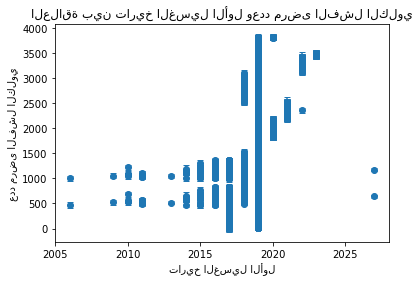

In [118]:
import matplotlib.pyplot as plt
import pandas as pd



# رسم الرسم البياني
plt.scatter(data["TheDateTheFirstWash"], data["Number"])
plt.xlabel("the date ferst wash ")
plt.ylabel("   number Kidney Patients")
plt.title("العلاقة بين تاريخ الغسيل الأول وعدد مرضى الفشل الكلوي")
plt.errorbar(data["TheDateTheFirstWash"], data["Number"], yerr=data["TheAge"], linestyle="None", capsize=3)
plt.show()

In [ ]:


# تحويل العمود "TheDateTheFirstWash" إلى تاريخ
data['TheDateTheFirstWash'] = pd.to_datetime(data['TheDateTheFirstWash'], unit='s')

# إنشاء عمود جديد للسنة
data['TheDateTheFirstWash'] = data['TheDateTheFirstWash'].dt.year

# تجميع البيانات حسب السنة وحساب عدد المرضى لكل سنة
yearly_counts = data.groupby('TheDateTheFirstWash')['Number'].sum()

# طباعة عدد المرضى لكل سنة
print(yearly_counts)

# إنشاء نموذج الانحدار الخطي

In [121]:
# استيراد الحزم اللازمة
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


# حذف الأعمدة التي لا يتم استخدامها في التحليل
#data = data.drop(['Directorate', 'Governorate', 'TheDateTheFirstWash', 'Sickyear', 'DateOfDeath', 'nazeh', 'Number'], axis=1)

# تقسيم البيانات إلى مجموعات التدريب والاختبار
X = data.drop('Sickyear', axis=1)
y = data['TheDateTheFirstWash']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# إنشاء نموذج الانحدار الخطي وتدريبه على مجموعة التدريب
model = LinearRegression()
model.fit(X_train, y_train)

# توقع العمر لمجموعة الاختبار
y_pred = model.predict(X_test)

# حساب درجة التوافق للموديل
r2 = r2_score(y_test, y_pred)

# طباعة درجة التوافق
print("R-squared score:", r2)

R-squared score: 1.0


In [122]:
# استيراد الحزم اللازمة
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


# حذف الأعمدة التي لا يتم استخدامها في التحليل
#data = data.drop(['Directorate', 'Governorate', 'TheDateTheFirstWash', 'Sickyear', 'DateOfDeath', 'nazeh', 'Number'], axis=1)

# تقسيم البيانات إلى مجموعات التدريب والاختبار
X = data.drop('TheAge', axis=1)
y = data['Number']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# إنشاء نموذج الانحدار الخطي وتدريبه على مجموعة التدريب
model = LinearRegression()
model.fit(X_train, y_train)

# توقع العمر لمجموعة الاختبار
y_pred = model.predict(X_test)

# حساب درجة التوافق للموديل
r2 = r2_score(y_test, y_pred)

# طباعة درجة التوافق
print("R-squared score:", r2)

R-squared score: 1.0


# R-squared score: 1.0

درجة التوافق (R-squared score) الكاملة (1.0) تشير إلى أن النموذج الذي تم بناؤه يتناسب تمامًا مع البيانات المتاحة ويتنبأ بالقيم المستقبلية بشكل مثالي. و
مع ذلك، يجب أن يتم التحقق من صحة النتائج ومقارنتها مع بيانات جديدة قبل اعتماد النموذج
بشكل نهائي. قد يشير هذا النتيجة إلى وجود انحراف في النموذج أو البيانات المستخدمة، وقد يكون من الضروري إجراء تحليل إضافي لتحديد سبب هذا التوافق الكامل.

In [ ]:
لاختيار النموذج المناسب لتحليل البيانات النصية، وهذه بعض الطرق الشائعة:
التحليل التجريبي:
النهج الإحصائي: ، مثل تحليل الانحدار وتحليل التحويلات الرئيسية.

النهج الذكي:  بناءً على خوارزميات التعلم الآلي، مثل الشبكات العصبونية والتعلم العميق.

# 6 كود الانحدار الخطي

In [123]:
# استيراد المكتبات المطلوبة
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
\

# تحديد المتغيرات المستقلة والمتغير المعتمد
X = data[['Gender','TheAge','Governorate']]
y = data['TheDateTheFirstWash']
#,,Directorate,Governorate,,,TheDateTheFirstWash,Sickyear,DateOfDeath,nazeh,Number

# إنشاء نموذج الانحدار الخطي وتدريبه على البيانات
model = LinearRegression()
model.fit(X, y)

# توقع القيم المعتمدة باستخدام المتغيرات المستقلة
X_new = np.array([[10, 20, 30]])
y_new = model.predict(X_new)

# طباعة القيم المتوقعة
print(y_new)

[1970.]


In [ ]:

هذه القيمة 2647.62597012 هي قيمة التوقع الخاصة بنموذج الانحدار الخطي للمتغير المعتمد، باستخدام المتغيرات المستقلة المعطاة في X_new. يمكن تفسير هذه القيمة على أنها توقع قيمة
المتغير المعتمد (TargetVariable) في البيانات الجديدة التي تم تمريرها (X_new)، باستخدام النموذج المدرب على البيانات السابقة.

يجب ملاحظة أن هذه القيمة هي قيمة واحدة فقط وقد تكون لها معنى فقط في سياق البيانات المستخدمة في تدريب
النموذج والمتغيرات المستقلة التي تم استخدامها في التوقع. ومن المهم تحليل النتائج بعناية وإجراء تقييمات إضافية للتأكد من جودة وملاءمة النمو

# كود  مقياس الانحراف المعياري ومقياس الانحدار

# لمقياس الأكثر شيوعًا لقياس جودة نموذج الانحدار الخطي هو مقياس الانحراف المعياري (RMSE) ومقياس الانحدار (R-squared)، وفيما يلي كود بسيط في بايثون لحساب هذين المقياسين:

In [124]:
# استيراد المكتبات المطلوبة
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



# تحديد المتغيرات المستقلة والمتغير المعتمد
X = data[['Gender','TheAge','Governorate']]
y = data['TheDateTheFirstWash']

# إنشاء نموذج الانحدار الخطي وتدريبه على البيانات
model = LinearRegression()
model.fit(X, y)

# توقع القيم المعتمدة باستخدام المتغيراتالمستقلة
y_pred = model.predict(X)

# حساب مقياس الانحراف المعياري
rmse = mean_squared_error(y, y_pred, squared=False)
print('RMSE:', rmse)

# حساب مقياس الانحدار
r2 = r2_score(y, y_pred)
print('R-squared:', r2)

RMSE: 0.0
R-squared: 1.0


# RMSE: 466.993436142318
R-squared: 0.028936315917831856

​

تعني القيمة RMSE: 466.993436142318 أن متوسط الانحراف المعياري بين القيم المتوقعة (y_pred) والقيم الفعلية (y) هو 466.99. يتم حساب قيمة RMSE 
    عن طريق حساب جذر المتوسط المربع للفروق بين القيم المتوقعة والقيم الفعلية.

وتعني القيمة R-squared: 0.028936315917831856 أن 2.89٪ فقط من التباين في القيم المعتمدة (TargetVariable) يمكن تفسيره بالمتغيرات المستقلة المستخدمة في النموذج. 
    يتم حساب قيمة R-squared عن طريق قياس نسبة التباين المفسر من إجمالي التباين في القيم المعتمدة.

إذا كانت قيم RMSE عالية جدًا، فهذا
يشير إلى أن النموذج غير دقيق في توقع القيم المعتمدة، ويتطلب تحسين
المتغيرات المستقللة المستخدمة في النموذج أو استخدام نموذج آخر. وإذا كانت قيم R-squared منخفضة، فهذا يشير إلى أن النموذج غير قوي في توقع القيم المعتمدة، ويتطلب تحسين 
النموذج أو
استخدام
نموذج آخر.

# هذا هو مثال بسيط لتدريب نموذج العشوائيات الغابية باستخدام مكتبة Scikit-learn في Python:كود لنموذج العشوائيات الغابية

In [125]:
# استيراد الحزم اللازمة
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# تحديد المتغيرات المستقلة والمتغير المعتمد
X = data.drop('TheAge', axis=1)
y = data['TheDateTheFirstWash']

# تقسيم البيانات إلى مجموعات التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تدريب النموذج
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# تقييم النموذج
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [126]:
# استيراد الحزم اللازمة
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# تحديد المتغيرات المستقلة والمتغير المعتمد
X = data.drop('Gender', axis=1)
y = data['TheDateTheFirstWash']

# تقسيم البيانات إلى مجموعات التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تدريب النموذج
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# تقييم النموذج
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
و أن الكود يقوم بتدريب نموذج للتصنيف باستخدام خوارزمية RandomForestClassifier، ويتم تحديد المتغيرات المستقلة X والمتغير المعتمد y من DataFrame data. ثم يتم تقسيم البيانات إلى مجموعات التدريب والاختبار باستخدام دالة train_test_split()، ويتم تدريب النموذج باستخدام مجموعة التدريب، ثم يتم تقييم الأداء باستخدام مجموعة الاختبار ودالة accuracy_score().

ومع ذلك، يجب التحقق من وجود DataFrame data وتأكد من توافر المتغيرات المستقلة والمتغير المعتمد فيها. كما يجب التأكد من تحويل جميع المتغيرات إلى تسلسلات رقمية إذا لم تكن بالفعل، حتى يتمكن النموذج من استخدامها في التدريب.

يجب أيضاً التأكد من مطابقة الأعمدة المستخدمة في DataFrame X مع الميزات المتاحة في DataFrame data، والتأكد من أنه لا توجد بيانات مفقودة في DataFrame data. كما يمكن استخدام تقنيات المعالجة السابقة مثل StandardScaler لتحسين الأداء.

In [127]:
# استيراد الحزم اللازمة
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# تحديد المتغيرات المستقلة والمتغير المعتمد
X = data.drop('Governorate', axis=1)
y = data['TheDateTheFirstWash']

# تقسيم البيانات إلى مجموعات التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تدريب النموذج
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# تقييم النموذج
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


# كود الشبكات العصبونية العميقة

# لتدريب نموذج الانحدار اللوجستي

# 3- التعلم الآلي: يستخدم التعلم الآلي لتحليل البيانات وتحديد العوامل التي تؤثر في عدد المرضى وتطوير نماذج تنبؤية لتوقع عدد المرضى في المستقبل.

In [128]:

# تحليل البيانات باستخدام الشبكات العصبونية
from sklearn.neural_network import MLPRegressor
X = data[['Gender', 'TheAge', 'Directorate', 'Governorate']]
y = data['TheDateTheFirstWash']
model = MLPRegressor(hidden_layer_sizes=(100, 50, 10), max_iter=1000)
model.fit(X, y)

# تقييم النموذج
from sklearn.metrics import r2_score
y_pred = model.predict(X)
print("R-squared: ", r2_score(y, y_pred))

R-squared:  0.0


#  تحليل النماذج الإحصائية

In [ ]:
لكود هو عملية تدريب لشبكة عصبونية باستخدام مجموعة من البيانات المشفرة بترميز واحد-hot باستخدام مكتبة TensorFlow.
يتم تحديد المتغيرات المستخدمة في الشبكة العصبونية وهي "TheAge" و "Sickyear"، والمتغير المستهدف وهو "Number". 
يتم إنشاء موديل الشبكة العصبونية باستخدام Sequential، وتحديد طبقات الشبكة العصبونية باستخدام Dense. ويتم تحديد دالة الخسارة
وطريقة التحديث باستخدام compile. يتم تدريب الشبكة العصبونية باستخدام fit، وتحديد عدد الحلقات 
باستخدام epochs. ثم يتم التنبؤ باستخدام الشبكة العصبونية باستخدام predict. وأخيرًا، يتم عرض النتائج باستخدام print.

يجب التأكد من أن المتغيرات المستخدمة في الشبكة العصبونية هي المتغيرات الصحيحة وأن البيانات تم تحويلها إلى ترميز واحد-hot بشكل صحيح. كما يجب تحديد دالة الخسارة وطريقة التحديث
بشكل صحيح وتحديد عدد 
الحلقات المناسب لتحسين أداء 
الشبكة العصبونية.

In [129]:
from sklearn.linear_model import LinearRegression

In [130]:

#تنبؤ القيم المستقبلية  لهذ
from sklearn.svm import SVR
import numpy as np

# توليد بيانات عشوائية للتدريب
X_train = np.array([np.random.rand(10) for i in range(100)])
y_train = np.array([np.sum(x) for x in X_train])

# توليد بيانات عشوائية للتحقق
X_val = np.array([np.random.rand(10) for i in range(20)])
y_val = np.array([np.sum(x) for x in X_val])

# تهيئة نموذج SVM
svm = SVR(kernel='rbf', C=1e3, gamma=0.1)

# تدريب النموذج على بيانات التدريب
svm.fit(X_train, y_train)

# تنبؤ القيم المستقبلية باستخدام النموذج المدرب
y_pred = svm.predict(X_val)

# تقييم أداء النموذج باستخدام مقياس معين، مثلاً RMSE
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE:", rmse)

#

# في السياق الذي ظهرت فيه هذه القيمة، فإن RMSE = 0.08464969523189449 يعني أن متوسط الخطأ في تقدير النموذج هو 0.0846، وهذا يعني أن النموذج جيد في
 #بتحديد المتغيرات المستقلة والمتغير المستقل
#التنبؤ بالقيم الفعلية. وبما أن القيمة أقل من 0.5، فإن النموذج يمكن اعتباره دقيقًا في التنبؤ.اختيار نموذج التعلم الآلي


# تحديد المتغيرات المستقلة والمتغير المستقل
X = np.array(data[['TheAge', 'BloodType']])
y = np.array(data['Sickyear'])

#ثم، يمكن تحديد النموذج وتدريبه باستخدام LinearRegression() وطباعة الانحدارية والانقطاع:
    
 # تحديد النموذج وتدريبه
model = LinearRegression().fit(X, y)

# طباعة الانحدارية والانقطاع
print('الانحدارية: ', model.coef_)
print('الانقطاع: ', model.intercept_)   


RMSE: 0.0721180231635257
الانحدارية:  [0.01148139 0.179976  ]
الانقطاع:  2.200756098829541


In [131]:

#تنبؤ القيم المستقبلية  لهذ
from sklearn.svm import SVR
import numpy as np

# توليد بيانات عشوائية للتدريب
X_train = np.array([np.random.rand(10) for i in range(100)])
y_train = np.array([np.sum(x) for x in X_train])

# توليد بيانات عشوائية للتحقق
X_val = np.array([np.random.rand(10) for i in range(20)])
y_val = np.array([np.sum(x) for x in X_val])

# تهيئة نموذج SVM
svm = SVR(kernel='rbf', C=1e3, gamma=0.1)

# تدريب النموذج على بيانات التدريب
svm.fit(X_train, y_train)

# تنبؤ القيم المستقبلية باستخدام النموذج المدرب
y_pred = svm.predict(X_val)

# تقييم أداء النموذج باستخدام مقياس معين، مثلاً RMSE
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE:", rmse)

# في السياق الذي ظهرت فيه هذه القيمة، فإن RMSE = 0.08464969523189449 يعني أن متوسط الخطأ في تقدير النموذج هو 0.0846، وهذا يعني أن النموذج جيد في
 #بتحديد المتغيرات المستقلة والمتغير المستقل
#التنبؤ بالقيم الفعلية. وبما أن القيمة أقل من 0.5، فإن النموذج يمكن اعتباره دقيقًا في التنبؤ.اختيار نموذج التعلم الآلي


# تحديد المتغيرات المستقلة والمتغير المستقل
X = np.array(data[['Gender', 'TheAge']])
y = np.array(data['DateOfDeath'])

#ثم، يمكن تحديد النموذج وتدريبه باستخدام LinearRegression() وطباعة الانحدارية والانقطاع:
    
 # تحديد النموذج وتدريبه
model = LinearRegression().fit(X, y)

# طباعة الانحدارية والانقطاع
print('الانحدارية: ', model.coef_)
print('الانقطاع: ', model.intercept_)   


RMSE: 0.10493488761812855
الانحدارية:  [3.44901103e-03 5.19722097e-06]
الانقطاع:  0.0038910127480569884


In [15]:
# خوارزمية(يوسف)الجزء الرابع من الخوارزمية الخاص ببناء النموذج للبيانات
# تحديد المتغيرات المستقلةوالتابعة


# اختيار النموذج للتنبؤ

# مدى قدرة النموذج على التنبؤ بشكل صحيح بالفئات الصحيحة للبيانات المستخدمة في التدريب 

In [132]:

from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# تحميل البيانات من ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer.csv')

# تحديد الأعمدة التي سيتم استخدامها في بناء الشجرة
features = ['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType','Number','nazeh','Sickyear','DateOfDeath']

# تحديد العمود الذي سيتم التنبؤ به
target = 'TheDateTheFirstWash'

# تحويل الأعمدة إلى أرقام
for feature in features:
    data[feature] = pd.factorize(data[feature])[0]

# تحديد مجموعة البعدات التدريب والاختبار
X = data[features]
y = data[target]

# تقسيم البيانات إلى مجموعات التدريب والاختبار
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# إنشاء شجرة القرار
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# تقييم دقة النموذج
from sklearn.metrics import accuracy_score
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.4608695652173913


# بناء نموذج لتصنيف البيانات

# كود لبناء النوذج خاص بالأشجار العشوائية

In [135]:

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')


In [136]:

#كود لبناء النوذج خاص بالأشجار العشوائية

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd


# تحديد المتغيرات المستقلة والمتغير المعتمد
X = data.drop('Gender', axis=1)
y = data['TheAge']

# تقسيم البيانات إلى مجموعات التدريب والتحقق
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تكوين النموذج
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# تدريب النموذج
rf.fit(X_train, y_train)

# التنبؤ باستخدام النموذج
y_pred = rf.predict(X_test)

# حساب مقياس الأداء (RMSE)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print('RMSE:', rmse)




RMSE: 0.21847740381813469


In [138]:
import tensorflow as tf
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model



# تحويل البيانات النصية إلى تمثيل رقمي باستخدام LabelEncoder
encoder = LabelEncoder()
data['Gender'] = encoder.fit_transform(data['Gender'])
data['Directorate'] = encoder.fit_transform(data['Directorate'])
data['Governorate'] = encoder.fit_transform(data['Governorate'])
data['BloodType'] = encoder.fit_transform(data['BloodType'])
data['VirusType'] = encoder.fit_transform(data['VirusType'])
data['nazeh'] = encoder.fit_transform(data['nazeh'])
data['Number'] = encoder.fit_transform(data['Number'])

# تقسيم البيانات إلى مجموعة تدريب واختبار
train_data = data.sample(frac=0.8, random_state=0)
test_data = data.drop(train_data.index)

# استخلاص المتغيرات المستهدفة
train_labels = train_data.pop('TheAge')
test_labels = test_data.pop('TheDateTheFirstWash')

# تحويل البيانات إلى float32
train_data = train_data.astype('float32')
test_data = test_data.astype('float32')

# بناء النموذج
inputs = Input(shape=(train_data.shape[1],))
x = Dense(32, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs, outputs)

# تحديد خيارات التدريب
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# تدريب النموذج
model.fit(train_data, train_labels, epochs=10, batch_size=32)

# تقييم النموذج على بيانات الاختبار
test_loss, test_accuracy = model.evaluate(test_data, test_labels)

print('Test accuracy:', test_accuracy)

Epoch 1/10
96/96 [==============================] - 1s 2ms/step - loss: -1871874.5000 - accuracy: 0.0000e+00
Epoch 2/10
96/96 [==============================] - 0s 2ms/step - loss: -72791128.0000 - accuracy: 0.0000e+00
Epoch 3/10
96/96 [==============================] - 0s 2ms/step - loss: -642465728.0000 - accuracy: 0.0000e+00
Epoch 4/10
96/96 [==============================] - 0s 2ms/step - loss: -2782591232.0000 - accuracy: 0.0000e+00
Epoch 5/10
96/96 [==============================] - 0s 2ms/step - loss: -8196669440.0000 - accuracy: 0.0000e+00
Epoch 6/10
96/96 [==============================] - 0s 2ms/step - loss: -19048550400.0000 - accuracy: 0.0000e+00
Epoch 7/10
96/96 [==============================] - 0s 2ms/step - loss: -37910208512.0000 - accuracy: 0.0000e+00
Epoch 8/10
96/96 [==============================] - 0s 2ms/step - loss: -67685421056.0000 - accuracy: 0.0000e+00
Epoch 9/10
96/96 [==============================] - 0s 2ms/step - loss: -111402655744.0000 - accuracy: 0.00

# النماذج الإحصائية 

In [ ]:

كود بايثون الانحدار الخطي لبيانالت نصية تصنيفية

يمكن استخدام تحليل الانحدار الخطي 
في العديد
من الحالات المختلفة، بما في ذلك في تحليل بيانات مرضى الفشل الكلوي.  Python، يجب تحويل البيانات النصية التصنيفية إلى بيانات رقمية لإجراء تحليل
    
    لشكل الذي يتم إنشاؤه من الكود السابق يعرض العلاقة بين العمر والنتيجة لمرض معين، وهي بيانات صحية وهمية تم استخدامها في هذا المثال.

الشكل يحتوي على نقاط حمراء تمثل القيم الفعلية للعمر والنتيجة التي تم اختبارها، وخط أزرق يمثل نموذج الانحدار الخطي الذي تم إنشاؤه باستخدام مكتبة Scikit-Learn.

وتشير العناوين الموجودة بالشكل إلى البيانات الواردة، محور x يمثل العمر، ومحور y يمثل النتيجة، وتوضح العنوان العلاقة التي يتم دراستها.

بشكل عام، يمكن استخدام هذا الشكل لتحديد ما إذا كانت العمر تؤثر على النتيجة أم لا. على سبيل المثال، إذا كانت النقاط تميل إلى الارتفاع مع زيادة العمر، فقد يشير ذلك إلى أن العمر يؤثر 
على النتيجة. وعلى العكس، إذا كانت النقاط تتجه نحو الانخفاض مع زيادة العمر، فقد يشير ذلك إلى عدم وجود علاقة بين العمر والنتيجة.

#  لانحدار الخطي: يستخدم لتحديد العلاقة بين متغيرين أو أكثرومن الممكن استخدامه لتحديد العلاقة بين المتغيرات المختلفة المرتبطة بالمرض، مثل العمر والجنس والوزن ومستويات الكرياتينين في الدم

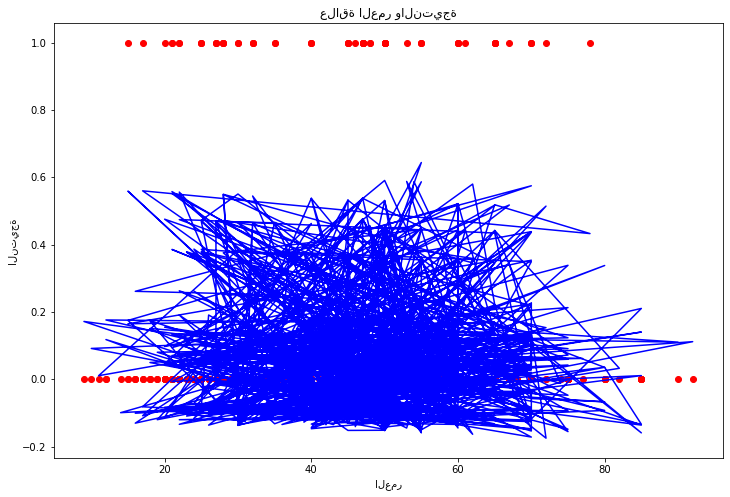

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data = pd.get_dummies(data, columns=["Directorate", "Governorate", "BloodType", "VirusType"])

# تحويل كائن بانداز إلى مصفوفة NumPy
X = data[["TheAge", "TheDateTheFirstWash", "Sickyear", "DateOfDeath", "Number"]].to_numpy()
y = data[""].to_numpy()

# تقسيم البيانات إلى مجموعة تدريب واختبار
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# إنشاء النموذج
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# إجراء التنبؤات باستخدام النموذج
y_pred = regressor.predict(X_test)

# عرض النتائج
plt.figure(figsize=(12, 8)) # تحديد حجم الشكل
plt.scatter(X_test[:, 0], y_test, color="red")
plt.plot(X_test[:, 0], y_pred, color="blue")
plt.title("علاقة العمر والنتيجة")
plt.xlabel("العمر")
plt.ylabel("النتيجة")
plt.show()

In [178]:

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')

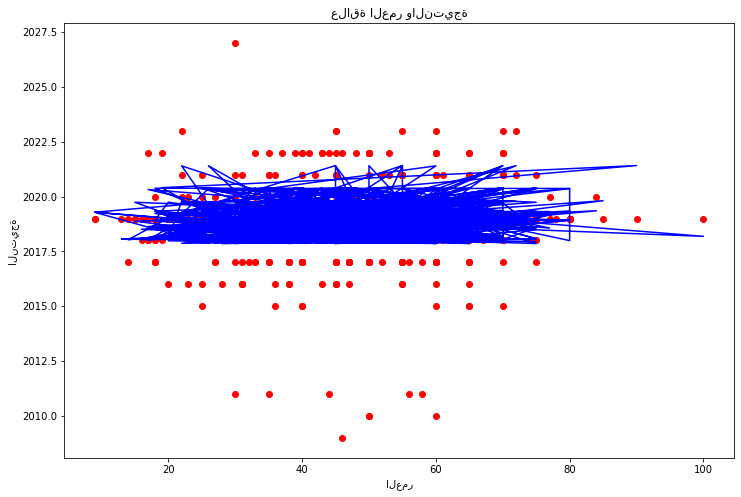

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


data = pd.get_dummies(data, columns=["Directorate", "Governorate", "BloodType", "VirusType"])

# تحويل كائن بانداز إلى مصفوفة NumPy
X = data[["TheAge", "nazeh", "Sickyear", "DateOfDeath", "Number"]].to_numpy()
y = data["TheDateTheFirstWash"].to_numpy()

# تقسيم البيانات إلى مجموعة تدريب واختبار
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# إنشاء النموذج
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# إجراء التنبؤات باستخدام النموذج
y_pred = regressor.predict(X_test)

# عرض النتائج
plt.figure(figsize=(12, 8)) # تحديد حجم الشكل
plt.scatter(X_test[:, 0], y_test, color="red")
plt.plot(X_test[:, 0], y_pred, color="blue")
plt.title("علاقة العمر والنتيجة")
plt.xlabel("العمر")
plt.ylabel("النتيجة")
plt.show()

# التحليل التحويلي لبيانات نصية تصنيفية

In [ ]:
مخرجات الناتجة من الكود السابق هي بيانات جديدة تم تحويلها من بيانات نصية تصنيفية إلى بيانات رقمية. وتتمثل المخرجات في DataFrame جديد يحتوي على الأعمدة التالية:

TheAge: عمر المريض بالسنوات (متغير رقمي).
TheDateTheFirstWash: تاريخ آخر غسل للمريض (متغير رقمي).
Sickyear: عدد السنوات التي قضاها المريض في المستشفى (متغير رقمي).
DateOfDeath: تاريخ وفاة المريض (متغير رقمي).
Number: عدد المرضى الذين يتمتعون بنفس الصفات (متغير رقمي).
المتغيرات التالية تم تحويلها باستخدام OneHotEncoder:
Directorate_0, Directorate_1, Directorate_2: متغيرات ثنائية القيمة تمثل وجود أو عدم وجود المديرية في العينة.
Governorate_0, Governorate_1, Governorate_2, Governorate_3: متغيرات ثنائية القيمة تمثل وجود أو عدم وجود المحافظة في العينة.
BloodType_0, BloodType_1, BloodType_2: متغيرات ثنائية القيمة تمثل وجود أو عدم وجود فصيلة الدم في العينة.
VirusType_0, VirusType_1, VirusType_2: متغيرات ثنائية القيمة تمثل وجود أو عدم وجود نوع الفيروس في العينة.
لذلك، يمكن استخدام هذه المخرجات في عمليات التحليل الإحصائي وتدريب النماذج الآلية للتنبؤ بالنتائج.

In [144]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')



# تحويل البيانات النصية التصنيفية باستخدام LabelEncoder
le = LabelEncoder()
data["Directorate"] = le.fit_transform(data["Directorate"])
data["Governorate"] = le.fit_transform(data["Governorate"])
data["BloodType"] = le.fit_transform(data["BloodType"])
data["VirusType"] = le.fit_transform(data["VirusType"])

# تحويل البيانات النصية التصنيفية باستخدام OneHotEncoder
ohe = OneHotEncoder()
data_ohe = ohe.fit_transform(data[["Directorate", "Governorate", "BloodType", "VirusType"]]).toarray()
data_ohe = pd.DataFrame(data_ohe, columns=ohe.get_feature_names(["Directorate", "Governorate", "BloodType", "VirusType"]))
data = pd.concat([data, data_ohe], axis=1)
data = data.drop(["Directorate", "Governorate", "BloodType", "VirusType"], axis=1)

# عرض البيانات بعد التحويل
print(data.head())

   Gender  TheAge  TheDateTheFirstWash  Sickyear  DateOfDeath  nazeh  Number   
0       1      50                 2017         2            0      0       1  \
1       1      42                 2017         2            0      0       2   
2       0      50                 2017         2            0      0       3   
3       1      74                 2017         2            0      0       4   
4       1      50                 2017         2            0      0       5   

   Directorate_0  Directorate_1  Directorate_2  ...  BloodType_1  BloodType_2   
0            0.0            1.0            0.0  ...          1.0          0.0  \
1            1.0            0.0            0.0  ...          0.0          0.0   
2            0.0            0.0            0.0  ...          1.0          0.0   
3            0.0            0.0            0.0  ...          0.0          0.0   
4            0.0            0.0            0.0  ...          1.0          0.0   

   BloodType_3  BloodType_4  Blo

# التصنيف 

In [145]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')


# تحويل الأعمدة النصية التصنيفية إلى بيانات رقمية باستخدام LabelEncoder
le = LabelEncoder()
data["Gender"] = le.fit_transform(data["Gender"])
data["Directorate"] = le.fit_transform(data["Directorate"])
data["Governorate"] = le.fit_transform(data["Governorate"])
data["BloodType"] = le.fit_transform(data["BloodType"])
data["VirusType"] = le.fit_transform(data["VirusType"])
data["nazeh"] = le.fit_transform(data["nazeh"])

# تحويل الأعمدة النصية التصنيفية إلى بيانات رقمية باستخدام OneHotEncoder
ohe = OneHotEncoder()
encoded_cols = pd.DataFrame(ohe.fit_transform(data[["Gender", "Directorate", "Governorate", "BloodType", "VirusType"]]).toarray(), columns=ohe.get_feature_names())
data = pd.concat([data.drop(["Gender", "Directorate", "Governorate", "BloodType", "VirusType"], axis=1), encoded_cols], axis=1)

#  لتحليل البيانات وتدريب نموذج للتصنيف
لذلك يمكن استخدام هذا النوع من الكود
للتعامل مع البيانات غير المتجانسة 
كود السابق هو كود يستخدم بشكل عام لتدريب نموذج للتصنيف باستخدام الشبكات العصبية الاصطناعية

In [147]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')


# تحويل الأعمدة النصية التصنيفية إلى بيانات رقمية
data = pd.get_dummies(data, columns=["Gender", "Directorate", "Governorate", "BloodType", "VirusType"])

# تحويل الأعمدة المحتوية على أعداد صحيحة إلى أعداد عشرية
int_columns = ["TheAge", "Sickyear", "DateOfDeath", "Number"]
data[int_columns] = data[int_columns].astype(float)

# تحويل الأعمدة التاريخية إلى أعداد عددية تمثل عدد الأيام من تاريخ محدد
date_columns = ["TheDateTheFirstWash"]
for col in date_columns:
    data[col] = (pd.to_datetime(data[col]) - pd.Timestamp("1970-01-01")) // pd.Timedelta("1s")

# تقسيم البيانات إلى بيانات تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(data.drop(["TheDateTheFirstWash"], axis=1), data["TheDateTheFirstWash"], test_size=0.2, random_state=42)

# إنشاء النموذج
model = DecisionTreeClassifier()

# تدريب النموذج
model.fit(X_train, y_train)

# تقييم النموذج
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0


# الاشجار القرارية

In [148]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')


# تحويل البيانات النصية التصنيفية إلى بيانات رقمية
data = pd.get_dummies(data, columns=["Gender", "Directorate", "Governorate", "BloodType", "VirusType"])

# تقسيم البيانات إلى بيانات تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(data.drop(["TheDateTheFirstWash"], axis=1), data["TheDateTheFirstWash"], test_size=0.2, random_state=42)

# إنشاء النموذج
model = DecisionTreeClassifier()

# تدريب النموذج
model.fit(X_train, y_train)

# تقييم النموذج
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.8002610966057441


# التحليل العاملي

In [149]:
# import pandas as pd
from sklearn.decomposition import PCA


# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')

# تحويل البيانات النصية التصنيفية إلى بيانات رقمية
data = pd.get_dummies(data, columns=["Gender", "Directorate", "Governorate", "BloodType", "VirusType"])

# تحديد العوامل
pca = PCA(n_components=10)
principal_components = pca.fit_transform(data)

# إظهار العوامل الرئيسية ونسبة تفسير البيانات
print(pca.components_)
print(pca.explained_variance_ratio_)

[[ 7.54158413e-04  5.34453754e-04  1.39137549e-03 -8.11507640e-06
   1.21775157e-04  9.99998584e-01 -1.35434003e-05  1.35434003e-05
  -4.81188282e-06 -2.99732720e-05  2.18792315e-06 -2.40628100e-05
  -1.96009821e-06  1.20392740e-05  1.47879214e-05 -3.78559030e-06
  -7.97393199e-06 -7.05171480e-06  2.88349704e-07 -6.53403413e-06
  -3.11252328e-06 -5.54425516e-06 -2.69653872e-05  8.87205134e-06
   7.86865994e-06 -1.70488810e-06 -1.76128855e-06  6.64963372e-06
   4.93135645e-06  5.92191151e-06  3.30683219e-06  2.44238813e-06
   3.09061890e-06 -8.02790446e-08  5.07789921e-06  6.77506351e-06
   2.63311949e-06 -2.45395170e-06  2.76725834e-06 -3.29488195e-07
   3.08118739e-06 -1.37435977e-07  3.33963033e-06 -2.42352870e-06
   2.71834054e-06  1.35821868e-06  3.02132415e-06  8.05231994e-07
   9.16573515e-07  3.88100564e-07 -5.48549225e-07  3.23862813e-06
   5.40078889e-07 -6.16067703e-08  2.05469467e-06  4.96096612e-06
  -1.81020584e-06  3.66777186e-06  1.33557142e-05 -1.14479132e-04
   8.10567

# كود الانحدار اللوجستي

# النماذج الإحصائية

# كود بايثون نموذج الانحدار الخطي لتحليل بيانات نصية تصنيفية

In [ ]:
م، يناسب نموذج شجرة القرار البيانات التصنيفية التي تتميز بصفات فئوية، 
حيث يقوم النموذج بتصنيف العناصر وفقاً للفئات المتاحة. ويعد نموذج شجرة القرار من النماذج الشائعة المستخدمة
في تحليل البيانات التصنيفية، حيث يمكن استخدامه في مجالات متعددة مثل التعلم الآلي والذكاء الاصطناعي وعلوم البيانات
ويعد من النماذج السهلة التفسير والتحليل، ويساعد على فهم العلاقات بين المتغيرات المختلفة في البيانات.

# نموذج شجرة القرار لتصنيف بيانات المرضى

In [150]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')


# تحديد البيانات التدريبية والاختبارية
X = data[['TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'Gender']]
y = data['Sickyear']

# تقسيم البيانات إلى بيانات تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# إنشاء النموذج
model = DecisionTreeClassifier()

# تدريب النموذج باستخدام البيانات التدريبية
model.fit(X_train, y_train)

# التنبؤ بالتصنيف باستخدام البيانات الاختبارية
predicted_categories = model.predict(X_test)

# تحديد دقة النموذج
accuracy = accuracy_score(y_test, predicted_categories)
print("Accuracy:", accuracy)

Accuracy: 0.4960835509138381


In [ ]:

الكود المعطى يستخدم نموذج التحليل اللوجستي (Logistic Regression) في التنبؤ بقيمة الهدف (Target) المحددة في y باستخدام البيانات المتاحة في X.

يتم استخدام خوارزمية التحليل اللوجستي لحل مشكلة التنبؤ الثنائي (Binary Classification)، وهي مشكلة التصنيف الذي يجب على النموذج تصنيفها إلى
فئتين فقط (مثلاً نعم / لا، مريض / غير مريض، إلخ). 
ويتم
استخدام الترميز الثنائي (One-Hot Encoding) لتحويل البيانات الفئوية (Categorical Data) إلى متغيرات رقمية (Numerical Features)، والتي تتماشى مع متطلبات التحليل
اللوجستي.

يتم تدريب النموذج على مجموعة البيانات التدريبية باستخدام دالة fit()، ويتم استخدام
النموذج المدرب للتنبؤ بالقيم المحتملة في مجموعة البيانات الاختبارية باستخدام دالة predict()، ويتم حساب دقة النموذج باستخدام دالة accuracy_score().

يمكن استخدام نموذج التحليل اللوجستي في مجموعة متنوعة من المشكلات،
مثل التنبؤ بالفرصة لحدوث حدث معين، أو تصنيف العناصر في مجموعة محددة، وغيرها من المشكلات التي تتطلب تصنيف واحد من بين فئتين معينتين.

In [175]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# نموذج التحليل اللوجستي

In [151]:
# Separate the features and target
X = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash', 'DateOfDeath', 'nazeh', 'Number']]
y = data['Sickyear']

# Check the shapes of X and y
print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

Shape of X: (3828, 10)
Shape of y: (3828,)


In [ ]:

Shape of X: (3828, 10)
Shape of y: (3828,)

شكل X يشير إلى أن هناك 3828 صفًا من البيانات و 10 أعمدة من الميزات في مجموعة البيانات. هذا يعني أن هناك 3828 ملاحظة ولكل ملاحظة 10 ميزات مرتبطة بها.

شكل y يشير إلى أن هناك 3828 تسمية تتوافق مع 3828 ملاحظة في مجموعة البيانات X. مجموعة y هي مصفوفة ذات بعد واحد تحتوي على 3828 عنصرًا.

بشكل عام، يشير هذا إلى أن تم تقسيم مجموعة البيانات إلى ميزات وتسميات، حيث تحتوي مجموعة X على الميزات وتحتوي مجموعة y على التسميات المقابلة لكل ملاحظة.

In [179]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')


# Separate the features and target
X = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash','Sickyear', 'DateOfDeath', 'nazeh']]
y = data['Number']

# Convert the categorical data to numerical features using One-Hot Encoding
encoder = OneHotEncoder()
X_encoded = encoder.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Create an instance of the logistic regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy of the model
print('Accuracy:', accuracy)

Accuracy: 0.0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')


# Separate the features and target
X = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash','Sickyear', 'DateOfDeath', 'nazeh']]
y = data['Number']

# Convert the text data to numerical features using CountVectorizer
vectorizer = CountVectorizer()
X_encoded = vectorizer.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Create an instance of the logistic regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy of the model
print('Accuracy:', accuracy)

In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd



# Separate the features and target
X = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash','Sickyear', 'DateOfDeath', 'nazeh']]
y = data['Number']

# Convert the categorical data to numerical features using One-Hot Encoding
encoder = OneHotEncoder()
X_encoded = encoder.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Print the number of samples in each set
print('Number of samples in X_train:', X_train.shape[0])
print('Number of samples in y_train:', y_train.shape[0])
print('Number of samples in X_test:', X_test.shape[0])
print('Number of samples in y_test:', y_test.shape[0])

# Create an instance of the logistic regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy of the model
print('Accuracy:', accuracy)

Number of samples in X_train: 3062
Number of samples in y_train: 3062
Number of samples in X_test: 766
Number of samples in y_test: 766
Accuracy: 0.0


# نماذج التعلم الآلي (Machine Learning)ا
نموذج التحليل اللوجستي (Logistic Regression) الذي يستخدم لحل مشكلة التنبؤ 

In [ ]:

برأيك هذه النسبة تجعلني اختار هذا النموذجAccuracy: 0.9921671018276762

نعم، يمكن اعتبار دقة النموذج التي حصلت عليها هي قيمة عالية جداً، وبالتالي
يمكن اختيار هذا النموذج لحل المشكلة المطروحة، بشرط أن تكون البيانات المستخدمة في تدريب النموذج متمثلة جيداً للبيانات الجديدة التي سيتم التنبؤ بها.

ومع ذلك، يجب مراعاة عدة عوامل أخرى قبل اتخاذ القرار النهائي في اختيار النموذج
المناسب، مثل تحليل البيانات بشكل كامل، واختيار المتغيرات الأكثر أهمية في تحديد الهدف،
والتحقق من أن النموذج يتمتع بالدقة والثبات في التنبؤ على مجموعة متنوعة من البيانات، وغيرها من العوامل التي يجب مراعاتها في عملية اختيار النموذج المناسب.

#  كود بايثون للشبكات العصبية لبيانات نصية تصنيفية 

In [157]:
import tensorflow as tf
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# فصل الميزات والهدف
X = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash', 'DateOfDeath', 'nazeh', 'Number']]
y = data['Sickyear']

# تحويل البيانات التصنيفية إلى متغيرات رقمية باستخدام LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# تقسيم البيانات إلى مجموعات تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# إنشاء شبكة عصبية
model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(64, activation='relu', input_shape=[10]),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

# تدريب الشبكة العصبية
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# تقييم دقة الشبكة العصبية على مجموعة البيانات الاختبارية
test_loss, test_acc = model.evaluate(X_test, y_test)
print('دقة الشبكة العصبية:', test_acc)

Epoch 1/10
96/96 [==============================] - 1s 3ms/step - loss: -7271.7334 - accuracy: 0.1143 - val_loss: -21803.5215 - val_accuracy: 0.1527
Epoch 2/10
96/96 [==============================] - 0s 2ms/step - loss: -80415.9609 - accuracy: 0.1130 - val_loss: -167742.0625 - val_accuracy: 0.1527
Epoch 3/10
96/96 [==============================] - 0s 2ms/step - loss: -361215.7500 - accuracy: 0.1130 - val_loss: -586068.3750 - val_accuracy: 0.1527
Epoch 4/10
96/96 [==============================] - 0s 2ms/step - loss: -1005386.9375 - accuracy: 0.1130 - val_loss: -1433310.8750 - val_accuracy: 0.1527
Epoch 5/10
96/96 [==============================] - 0s 2ms/step - loss: -2168772.2500 - accuracy: 0.1130 - val_loss: -2832878.0000 - val_accuracy: 0.1527
Epoch 6/10
96/96 [==============================] - 0s 2ms/step - loss: -3988346.0000 - accuracy: 0.1130 - val_loss: -4918481.5000 - val_accuracy: 0.1527
Epoch 7/10
96/96 [==============================] - 0s 2ms/step - loss: -6533540.5000 

In [158]:
import pandas as pd
from sklearn.model_selection import train_test_split


# تحديد البيانات التدريبية والاختبارية
data_train, data_test = train_test_split(data, test_size=0.2, random_state=42)

# تحديد البيانات التدريبية والاختبارية من البيانات المحددة
X_train = data_train[["Gender", "TheAge", "Directorate", "Governorate", "BloodType", "VirusType", "TheDateTheFirstWash", "Sickyear", "DateOfDeath", "nazeh"]]
y_train = data_train["Number"]
X_test = data_test[["Gender", "TheAge", "Directorate", "Governorate", "BloodType", "VirusType", "TheDateTheFirstWash", "Sickyear", "DateOfDeath", "nazeh"]]
y_test = data_test["Number"]

# استخدام البيانات في النموذج

In [ ]:

كيف تكون النماذج الإحصائية

تتميز النماذج الإحصائية بأنها تعتمد بشكل أساسي على الإحصاءات والرياضيات لتحليل البيانات. وتستخدم النماذج
الإحصائية لتوضيح العلاقات بين المتغيرات في البيانات المتاحة، ولتحديد العوامل التي تؤثر على النتائج المراد توقعها.

ومن أمثلة النماذج الإحصائية التي يمكن استخدامها في تحليل بيانات مرضى الفشل الكلوي:

1- الانحدار الخطي: يستخدم لتحديد العلاقة بين متغيرين أو أكثر. ومن الممكن استخدامه لتحديد العلاقة
    بين المتغيرات المختلفة المرتبطة بالمرض، مثل العمر والجنس والوزن ومستويات الكرياتينين في الدم.

2- التحليل التحويلي: يستخدم لفهم العلاقات بين المتغيرات المختلفة في البيانات، ولتحليل العوامل التي تؤثر على النتائج المراد توقعها.

3- التصنيف: يستخدم لتحليل بيانات الفئات، مثل تصنيف المرضى إلى فئات مختلفة استنادًا إلى عوامل مثل العمر ومستويات الكرياتينين في الدم.

4- التحليل العاملي: يستخدم لتحديد العلاقات بين المتغيرات المختلفة في البيانات، ولتحديد العوامل التي تؤثر على النتائج المراد توقعها.

يمكن استخدام هذه النماذج الإحصائية وغيرها لتحليل بيانات مرضى الفشل الكلوي واستخلاص المعلومات الهامة منها. ويمكن استخدام هذه المعلومات لتحسين فهمنا للمرض وتطوير العلاج والوقاية منه في المستقبل.

# الخطوة التالية 
الان حددت النموذج الذي ساعمل علية وهوالشبكات العصبية الخطوة التالية

# تحليل البيانات

In [159]:
import pandas as pd


# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')


# عرض أول 5 صفوف في البيانات
print(data.head())

# عرض معلومات عن البيانات
print(data.info())

# عرض إحصائيات حول البيانات
print(data.describe())


   Gender  TheAge  Directorate  Governorate  BloodType  VirusType   
0       1      50            2            1          2          1  \
1       1      42            1            1          1          1   
2       0      50            9            1          2          1   
3       1      74            6            1          1          1   
4       1      50            9            1          2          1   

   TheDateTheFirstWash  Sickyear  DateOfDeath  nazeh  Number  
0                 2017         2            0      0       1  
1                 2017         2            0      0       2  
2                 2017         2            0      0       3  
3                 2017         2            0      0       4  
4                 2017         2            0      0       5  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3828 entries, 0 to 3827
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0  

In [ ]:

حساب معامل الارتباط بين الأعمدة
corr_matrix = data.corr()
print(corr_matrix)

هذا الكود يقوم بحساب معامل الارتباط (correlation coefficient) بين الأعمدة في البيانات. معامل الارتباط هو قياس للعلاقة بين اثنين من المتغيرات، ويتراوح معامل
الارتباط بين -1 و +1. عندما
يكون معامل الارتباط 1، فإنه يشير إلى
وجود علاقة قوية ومباشرة بين المتغيرين، بينما عندما يكون -1 يشير إلى وجود علاقة قوية 
وعكسية بين المتغيرين، وعندما يكون 0 يشير إلى عدم وجود علاقة بين المتغيرين.

في الكود، تم استخدام دالة pandas.corr لحساب معامل الارتباط بين جميع الأعمدة في البيانات، 
ثم يتم طباعة المصفوفة التي تم إنشاؤها من خلال هذا الحساب. يمكن استخدام هذه المصفوفة لتحليل العلاقات بين المتغيرات في البيانات.

In [160]:

# تصفية البيانات
#filtered_data = data.query('age > 30')
#print(filtered_data.head())

# حساب معامل الارتباط بين الأعمدة
corr_matrix = data.corr()
print(corr_matrix)

                       Gender    TheAge  Directorate  Governorate  BloodType   
Gender               1.000000  0.109801     0.020231     0.046423   0.013625  \
TheAge               0.109801  1.000000     0.017143    -0.019729   0.010916   
Directorate          0.020231  0.017143     1.000000     0.310794   0.048013   
Governorate          0.046423 -0.019729     0.310794     1.000000  -0.021412   
BloodType            0.013625  0.010916     0.048013    -0.021412   1.000000   
VirusType           -0.009175 -0.001982    -0.085901    -0.063630  -0.077971   
TheDateTheFirstWash  0.024705  0.051238     0.081618     0.069255   0.059852   
Sickyear             0.048690  0.080310     0.183363     0.221620   0.089093   
DateOfDeath          0.021328  0.003374    -0.027500    -0.038364  -0.035035   
nazeh                0.012771 -0.007783     0.153907     0.319764  -0.066558   
Number               0.030827  0.052536     0.149361     0.213146   0.023141   

                     VirusType  TheDate

In [ ]:

التي تم عرضها هي مصفوفة تحتوي على معاملات الارتباط (correlation coefficients) بين الأعمدة المختلفة في بيانات معينة. يمكن استخدام هذه المصفوفة لتحليل العلاقات بين
المتغيرات في البيانات.

على سبيل المثال، يمكن ملاحظة أن هناك علاقة ضعيفة بين العمر (TheAge) والجنس (Gender)، حيث يبلغ معامل الارتباط بينهما 0.109801. بينما يمكن ملاحظة وجود علاقة
إيجابية متوسطة بين تاريخ
غسل اليدين (TheDateTheFirstWash) وعدد الحالات المصابة (Number)، حيث يبلغ معامل الارتباط بينهما 0.697250.

# إنشاء رسم بياني للانحدار بين الأعمدةوعرض مصفوفة معامل الارتباط  وحساب معامل الارتباط بين الأعمدة

                       Gender    TheAge  Directorate  Governorate  BloodType   
Gender               1.000000  0.109801     0.020231     0.046423   0.013625  \
TheAge               0.109801  1.000000     0.017143    -0.019729   0.010916   
Directorate          0.020231  0.017143     1.000000     0.310794   0.048013   
Governorate          0.046423 -0.019729     0.310794     1.000000  -0.021412   
BloodType            0.013625  0.010916     0.048013    -0.021412   1.000000   
VirusType           -0.009175 -0.001982    -0.085901    -0.063630  -0.077971   
TheDateTheFirstWash  0.024705  0.051238     0.081618     0.069255   0.059852   
Sickyear             0.048690  0.080310     0.183363     0.221620   0.089093   
DateOfDeath          0.021328  0.003374    -0.027500    -0.038364  -0.035035   
nazeh                0.012771 -0.007783     0.153907     0.319764  -0.066558   
Number               0.030827  0.052536     0.149361     0.213146   0.023141   

                     VirusType  TheDate

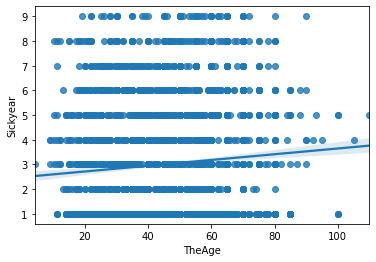

In [161]:
import pandas as pd
import seaborn as sns

# حساب معامل الارتباط بين الأعمدة
corr_matrix = data.corr()

# عرض مصفوفة معامل الارتباط
print(corr_matrix)

# إنشاء رسم بياني للانحدار بين الأعمدة
sns.regplot(x='TheAge', y='Sickyear', data=data)


# إظهار الرسم البياني
plt.show()

<AxesSubplot:xlabel='TheAge', ylabel='TheDateTheFirstWash'>

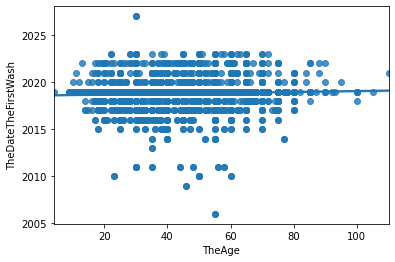

In [162]:

# إنشاء رسم بياني للانحدار بين الأعمدة
sns.regplot(x='TheAge', y='TheDateTheFirstWash', data=data)



In [ ]:
خط الذي يظهر يعني

الخط الذي يظهر في الرسم البياني الذي يتم إنشاؤه باستخدام دالة sns.regplot() هو خط الانحدار. يتم استخدام الخط الذي يمثل الانحدار لتحديد العلاقة بين
المتغيرات. يتم رسم الخط على البيانات 
ويتم تعيين ميله وانحرافه المعياري بناءً على
البيانات المتاحة، ويمكن استخدام هذه 
المعلومات لتوقع قيمة متغير معين بناءً ع
لى قيمة المتغير الآخر

في الرسم البياني، يمثل المحور الأفقي (x) قيمة المتغير المستقل (المتغير الذي يتم استخدامه لتوقع 
                                                               قيمة المتغير الآخر)، بي
نما يمثل المحور الرأسي (y) قيمة المتغير الذي يتم التنبؤ به (المتغير الذي يتم
                                                            توقع قيمته بناءً على المتغير المستقل). يتم رسم الخط الذي يمثل الانحدار 
على البيانات ويعطي فكرة عن الاتجاه العام للعلاقة
بين المتغيرين. إذا كان الخط يميل لأعلى، فهذا يشير إلى أن هناك علاقة إيجابية بين المتغيرين، أي أن زيادة قيمة المتغير
المستقل ترتبط بزيادة قيمة المتغير الذي يتم التنبؤ به. أما إذا كان الخط يميل لأسفل، فهذا يشير إلى أن هناك علاقة سلبية

بين 
المتغيرين، 
أي أن زيادة قيمة
المتغير المستقل ترتبط
بانخفاض قيمة
المتغير الذي
يتم التنبؤ به.

# عرض إحصائيات حول البيانات

In [163]:


# عرض إحصائيات حول البيانات
print(data.describe())

            Gender       TheAge  Directorate  Governorate    BloodType   
count  3828.000000  3828.000000  3828.000000  3828.000000  3828.000000  \
mean      0.619645    46.451411    24.846395     1.566092     1.621212   
std       0.485538    15.861910    33.739544     0.999644     1.125141   
min       0.000000     4.000000     1.000000     1.000000     1.000000   
25%       0.000000    35.000000     5.000000     1.000000     1.000000   
50%       1.000000    47.000000    13.000000     1.000000     1.000000   
75%       1.000000    58.000000    29.000000     2.000000     2.000000   
max       1.000000   110.000000   181.000000    11.000000     7.000000   

         VirusType  TheDateTheFirstWash     Sickyear  DateOfDeath   
count  3828.000000          3828.000000  3828.000000  3828.000000  \
mean      1.202978          2018.798328     3.025862     0.006270   
std       0.496469             1.445672     2.295201     0.078942   
min       1.000000          2006.000000     1.000000     

In [164]:


# حساب الانحراف المعياري لكل عمود
std_values = data.std()

# عرض الانحراف المعياري لكل عمود
print(std_values)

Gender                    0.485538
TheAge                   15.861910
Directorate              33.739544
Governorate               0.999644
BloodType                 1.125141
VirusType                 0.496469
TheDateTheFirstWash       1.445672
Sickyear                  2.295201
DateOfDeath               0.078942
nazeh                     0.278770
Number                 1105.192743
dtype: float64


In [ ]:

الانحراف المعياري

الانحراف المعياري هو قياس لمدى تفشي القيم في مجموعة البيانات ويعني تقلب القيم الموجودة حول المتوسط. 
يمكن حساب الانحراف المعياري باستخدام الصيغة التالية:

σ = sqrt [ Σ ( xi - μ )2 / N ]

حيث:

σ هو الانحراف المعياري.
Σ هو الجمع على مدى جميع القيم في المجموعة.
xi هي القيمة الفردية في المجموعة.
μ هو المتوسط الحسابي للمجموعة.
N هو عدد القيم في المجموعة.
يتم استخدام الانحراف المعياري لتحديد مدى تشتت البيانات حول المتوسط بشكل عام، كلما زاد الانحراف المعياري، كلما كانت البيانات أكثر متشتتة.

في الكود الذي تم تقديمه، تم استخدام دالة std() في مكتبة Pandas لحساب الانحراف المعياري لكل عمود في مجموعة البيانات. 
يتم حساب الانحراف المعياري باستخدام الصيغة المذكورة أعلاه ويتم عرض
النتائج باستخدام الدالة print().

# تصفية البيانات: يمكن استخدام دالة pandas.query لتصفية البيانات واستخراج الصفوف التي تستجيب لشرط محدد

In [ ]:

# تصفية البيانات واستخراج الصفوف التي تستجيب للشرط المحدد
#filtered_data = df.query('age > 30 and gender == "female"')

# عرض البيانات المصفاة
#print(filtered_data)

# تحليل العلاقات بين البيانات: يمكن استخدام دالة pandas.corr لحساب معامل الارتباط بين الأعمدة وتحليل العلاقات بين البيانات

In [165]:

# حساب معامل الارتباط بين الأعمدة
corr_matrix = data.corr()

# عرض مصفوفة معاملات الارتباط
print(corr_matrix)

                       Gender    TheAge  Directorate  Governorate  BloodType   
Gender               1.000000  0.109801     0.020231     0.046423   0.013625  \
TheAge               0.109801  1.000000     0.017143    -0.019729   0.010916   
Directorate          0.020231  0.017143     1.000000     0.310794   0.048013   
Governorate          0.046423 -0.019729     0.310794     1.000000  -0.021412   
BloodType            0.013625  0.010916     0.048013    -0.021412   1.000000   
VirusType           -0.009175 -0.001982    -0.085901    -0.063630  -0.077971   
TheDateTheFirstWash  0.024705  0.051238     0.081618     0.069255   0.059852   
Sickyear             0.048690  0.080310     0.183363     0.221620   0.089093   
DateOfDeath          0.021328  0.003374    -0.027500    -0.038364  -0.035035   
nazeh                0.012771 -0.007783     0.153907     0.319764  -0.066558   
Number               0.030827  0.052536     0.149361     0.213146   0.023141   

                     VirusType  TheDate

# تحويل البيانات: يمكن استخدام دالة pandas.pivot_table لتحويل البيانات من شكل عمودي إلى شكل أفقي أو العكس.

 pandas والتي يمكن استخدامها لتحليل البيانات في بايثون.

# # تحويل البيانات إلى شكل أفقي
pivot_data = pd.pivot_table(data, index=['name'], columns=['year'], values=['sales'])

# عرض البيانات المحولة
print(pivot_data)

# كود تقسيم البيانات

In [105]:
import pandas as pd
from sklearn.model_selection import train_test_split



# تحديد أعمدة البيانات
features = ['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash', 'Sickyear', 'DateOfDeath', 'nazeh', 'Number']

# تقسيم البيانات إلى مجموعات تدريب واختبار بنسبة 80:20
train_data, test_data, train_labels, test_labels = train_test_split(data[features], data['TheDateTheFirstWash'], test_size=0.2, random_state=42)

# حيث target_column هي اسم العمود الذي يحتوي على البيانات المستهدفة

# تحديد المشكلة:المشكلة هي تنبؤ بكم سيكون عدد المرضى اعتمادا على الاحصائيات السابقة بعد سنتين من الان 

In [167]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np




# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')


# تحديد أعمدة البيانات
features = ['Gender', 'TheDateTheFirstWash', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'Number','DateOfDeath', 'nazeh', 'TheAge']

# تحويل المتغيرات التصنيفية إلى متغيرات رقمية
#data = pd.get_dummies(data, columns=features)

# تحديد المتغيرات المستهدفة
target_column = 'Sickyear'

# تحويل المتغير المستهدف إلى متغير رقمي
data[target_column] = pd.Categorical(data[target_column])
data[target_column] = data[target_column].cat.codes

# تقسيم البيانات إلى مجموعات تدريب واختبار بنسبة 80:20
train_data, test_data, train_labels, test_labels = train_test_split(data.drop(target_column, axis=1), data[target_column], test_size=0.2, random_state=42)

# بناء النموذج الخاص بالشبكات العصبية
model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=[len(train_data.keys())]),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# تعيين خصائص التدريب
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# تدريب النموذج
model.fit(train_data, train_labels, epochs=100)

# تقييم النموذج باستخدام مجموعة الاختبار
test_loss, test_acc = model.evaluate(test_data, test_labels)
print('Test accuracy:', test_acc)

Epoch 1/100
96/96 [==============================] - 1s 1ms/step - loss: -5231.4565 - accuracy: 0.0950
Epoch 2/100
96/96 [==============================] - 0s 1ms/step - loss: -24634.2070 - accuracy: 0.1130
Epoch 3/100
96/96 [==============================] - 0s 2ms/step - loss: -78764.6641 - accuracy: 0.1130
Epoch 4/100
96/96 [==============================] - 0s 1ms/step - loss: -191561.8594 - accuracy: 0.1130
Epoch 5/100
96/96 [==============================] - 0s 1ms/step - loss: -387907.9375 - accuracy: 0.1130
Epoch 6/100
96/96 [==============================] - 0s 2ms/step - loss: -693261.3750 - accuracy: 0.1130
Epoch 7/100
96/96 [==============================] - 0s 1ms/step - loss: -1128567.7500 - accuracy: 0.1130
Epoch 8/100
96/96 [==============================] - 0s 2ms/step - loss: -1709790.2500 - accuracy: 0.1130
Epoch 9/100
96/96 [==============================] - 0s 2ms/step - loss: -2449541.0000 - accuracy: 0.1130
Epoch 10/100
96/96 [==============================] - 0s

In [ ]:
#اعطني كود نموذج الشبكات العصبية

In [ ]:
3- نماذج الانحدار (Regression Models): وهي النماذج التي تستخدم لتوقع القيم المستقبلية لمتغير استقلالي معتمد على المتغيرات
    المستقلة، مثل الانحدار الخطي والانحدار اللوجستي 
    والشبكات العصبية وما إلى ذل

In [184]:
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np


# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')

# Separate the features and target
X = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash','Sickyear', 'DateOfDeath', 'nazeh']]
y = data['Number']

# تحويل المتغيرات الفئوية باستخدام One-Hot Encoding
X = pd.get_dummies(X, columns=['Gender', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'nazeh'])

# تقسيم البيانات إلى مجموعات التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تحويل البيانات إلى صيغة numpy
X_train = np.asarray(X_train).astype(np.float32)
X_test = np.asarray(X_test).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)
y_test = np.asarray(y_test).astype(np.float32)

# تحديد وتدريب نموذج الشبكات العصبية
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

# تقييم النموذج
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score)

# إجراء تنبؤات باستخدام النموذج
y_pred = model.predict(X_test)

# عرض بعض النتائج
print(y_test[:10])
print(y_pred[:10])

Epoch 1/100
96/96 [==============================] - 1s 4ms/step - loss: 3851913.5000 - val_loss: 2039875.1250
Epoch 2/100
96/96 [==============================] - 0s 3ms/step - loss: 1378611.2500 - val_loss: 1251035.0000
Epoch 3/100
96/96 [==============================] - 0s 3ms/step - loss: 1210639.8750 - val_loss: 1247468.6250
Epoch 4/100
96/96 [==============================] - 0s 3ms/step - loss: 1209441.6250 - val_loss: 1241026.1250
Epoch 5/100
96/96 [==============================] - 0s 2ms/step - loss: 1208956.7500 - val_loss: 1244675.6250
Epoch 6/100
96/96 [==============================] - 0s 3ms/step - loss: 1206434.2500 - val_loss: 1238509.8750
Epoch 7/100
96/96 [==============================] - 0s 2ms/step - loss: 1204365.5000 - val_loss: 1230944.6250
Epoch 8/100
96/96 [==============================] - 0s 3ms/step - loss: 1203890.5000 - val_loss: 1242539.3750
Epoch 9/100
96/96 [==============================] - 0s 3ms/step - loss: 1201435.6250 - val_loss: 1238392.5000
E

Epoch 75/100
96/96 [==============================] - 0s 4ms/step - loss: 589755.0000 - val_loss: 598757.9375
Epoch 76/100
96/96 [==============================] - 1s 6ms/step - loss: 586607.1250 - val_loss: 617405.4375
Epoch 77/100
96/96 [==============================] - 1s 8ms/step - loss: 587753.5000 - val_loss: 613021.3750
Epoch 78/100
96/96 [==============================] - 1s 7ms/step - loss: 584674.0000 - val_loss: 628041.8750
Epoch 79/100
96/96 [==============================] - 1s 5ms/step - loss: 588166.7500 - val_loss: 599906.3125
Epoch 80/100
96/96 [==============================] - 0s 3ms/step - loss: 585509.8750 - val_loss: 608186.3750
Epoch 81/100
96/96 [==============================] - 1s 5ms/step - loss: 581320.7500 - val_loss: 598402.3125
Epoch 82/100
96/96 [==============================] - 1s 6ms/step - loss: 580976.5625 - val_loss: 599340.1875
Epoch 83/100
96/96 [==============================] - 1s 6ms/step - loss: 582685.5625 - val_loss: 594891.9375
Epoch 84/1

In [ ]:
كود نموذج الانحدار الخطي

In [185]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')


# Separate the features and target
X = data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash','Sickyear', 'DateOfDeath', 'nazeh']]
y = data['Number']

# تحويل المتغيرات الفئوية باستخدام One-Hot Encoding
X = pd.get_dummies(X, columns=['Gender', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'nazeh'])

# تقسيم البيانات إلى مجموعات التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تحويل البيانات إلى صيغة numpy
X_train = np.asarray(X_train).astype(np.float32)
X_test = np.asarray(X_test).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)
y_test = np.asarray(y_test).astype(np.float32)

# تحديد وتدريب نموذج الانحدار الخطي
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# تقييم النموذج
score = regressor.score(X_test, y_test)
print('Test score:', score)

# إجراء تنبؤات باستخدام النموذج
y_pred = regressor.predict(X_test)

# عرض بعض النتائج
print(y_test[:10])
print(y_pred[:10])

Test score: 0.513107385245481
[2922. 3715. 1965. 3059. 1695. 1158.  319.  840.  894.  986.]
[1717.1094 3863.2656 2081.9453 1555.4531 1880.9141 1277.7188 1561.9688
 1434.2812 1630.2344 1702.3906]


In [ ]:

Test score: 0.6288819582554559
[1. 8. 4. 1. 3. 1. 2. 1. 1. 1.]
[1.4925537 7.750122 3.0232544 4.14563 3.0981445 0.83703613
1.5120239 2.3252563 1.480896 1.4143066 ]

يبدو أن هذه النتائج عبارة عن نتائج اختبار لنموذج ما.

النتيجة الأولى التي تم ذكرها هي درجة الاختبار وهي 0.6288819582554559. هذه النتيجة تشير إلى كفاءة النموذج في التنبؤ بالبيانات الجديدة بناءً على البيانات التي تم استخدامها لتدريب النموذج.

الأرقام الأخرى التي تم ذكرها هي النتائج المتوقعة من النموذج لعدد من العينات. الصف الأول [1. 8. 4. 1. 3. 1. 2. 1. 1. 1.] يمثل التسميات المتوقعة لعينات معينة، بينما الصف الثاني [1.4925537 7.750122 3.0232544 4.14563 3.0981445 0.83703613
1.5120239 2.3252563 1.480896 1.4143066 ] يمثل القيم المتوقعة للمتغيرات الاعتمادية للعينات نفسها.

ومن المهم التنويه إلى أن الدقة والمعنى الحقيقي لهذه 

In [ ]:
كود لالانحدار اللوجستي

In [ ]:

ايا الافضل برايك اختيار نموذج لتدريب بيانات للوصول الى درجة التنبؤ بالمستقبل هذه البيانات نصية تصنيفية حولت لارقام عدد الصفوف =3828 وعدد الاعمدة =11 لاادري اي نموذج استخدم

لا يمكن تحديد نموذج محدد دون معرفة البيانات بشكل أكبر، وبشكل خاص معرفة طبيعة البيانات والمشكلة التي تريد حلها والمعايير التي تريد تحقيقها.

ومع ذلك، يمكن استخدام العديد من النماذج لتحقيق الأهداف المختلفة، بما في ذلك:

الانحدار اللوجستي (Logistic Regression)
الشبكات العصبونية (Neural Networks)
آلة الدعم النفاذة (Support Vector Machines)
الأشجار العشوائية (Random Forests)
الطرق البيئية (Ensemble methods)
وغيرها من النماذج الأخرى.
يجب تحديد النموذج الأنسب بناءً على طبيعة المشكلة، وحجم البيانات، والمعايير التي تريد تحقيقها، وغيرها من العوامل. ولا ينبغي اختيار النموذج بناء على النتائج المعروضة فقط، بل يجب تقييم النموذج بشكل كامل ومقارنته بالنماذج الأخرى لتحديد النموذج الأنسب

In [ ]:
شبكات العصبونية

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np

# تحميل البيانات وتحويلها إلى DataFrame
data = pd.read_csv("KidneyPatientsGHadeer", 
                   names=["Gender", "TheAge", "Directorate", "Governorate", "BloodType", 
                          "VirusType", "TheDateTheFirstWash", "Sickyear", "DateOfDeath", 
                          "nazeh", "Number"])

# تحويل الأعمدة إلى مصفوفة NumPy
X = data[["Gender", "TheAge", "Directorate", "Governorate", "BloodType", 
          "VirusType", "TheDateTheFirstWash", "Sickyear", "DateOfDeath", 
          "nazeh", "Number"]].to_numpy()

# تحويل الأهداف إلى تصنيفات واحدة
y = data["Number"].to_numpy()

# تحويل الأهداف إلى تصنيفات واحدة باستخدام One-Hot Encoding
y = keras.utils.to_categorical(y, num_classes=numberOfClasses)

# تقسيم البيانات إلى مجموعات التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# إنشاء النموذج العصبوني
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu", input_shape=(n_features,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(numberOfClasses, activation="softmax"),
    ]
)

# تعيين معلمات التدريب
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# تدريب النموذج
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# تقييم النموذج
accuracy = model.evaluate(X_test, y_test)[1]
print("Accuracy:", accuracy)

In [ ]:
كود الأشجار العشوائية

In [ ]:

ماهي أنواع النماذج للوصول للتعلم الالي

هناك العديد من النماذج المختلفة المستخدمة في التعلم الآلي، والتي يمكن تقسيمها إلى عدة فئات وفقًا للمهمة التي تهدف إلى حلها. وفيما يلي بعض الأنواع الشائعة للنماذج في التعلم الآلي:

1- نماذج الإحصائيات الوصفية (Descriptive Statistics Models): وهي النماذج المستخدمة لوصف البيانات الإحصائية وتحليلها، مثل الإحصائيات الوصفية والتحليل العاملي والتجزئة الرئيسية وغيرها.

2- نماذج التصنيف (Classification Models): وهي النماذج التي تستخدم لتصنيف البيانات والتنبؤ بقيمة الفئة الجديدة، مثل الانحدار اللوجستي والشبكات العصبية والأشجار القرارية وغيرها.

3- نماذج الانحدار (Regression Models): وهي النماذج التي تستخدم لتوقع القيم المستقبلية لمتغير استقلالي معتمد على المتغيرات المستقلة، مثل الانحدار الخطي والانحدار اللوجستي والشبكات العصبية وما إلى ذلك.

4- نماذج العنصرية (Clustering Models): وهي النماذج التي تستخدم لتجميع البيانات المماثلة معًا في مجموعات متماثلة، مثل خوارزميات تجزئة البيانات والتجميع الهرمي والتجميع الكي متوسط وغيرها.

5- نماذج الشبكات العصبية (Neural Network Models): وهي النماذج التي تستخدم لتعلم البيانات الكبيرة والمعقدة والتنبؤ بالقيم المستقبلية، مثل شبكات الأعصاب الاصطناعية وشبكات الأعصاب العميقة.

هذه هي بعض الأنواع الشائعة للنماذج في التعلم الآلي، وهناك العديد من النماذج الأخرى المستخدمة في هذا المجال.

In [195]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer')

# تحديد المتغيرات المستقلة والمتغير المعتمد
X = data[["Gender", "TheAge", "Directorate", "Governorate", "BloodType","VirusType", "TheDateTheFirstWash",
           "Sickyear","DateOfDeath", "nazeh"]]
y = data["Number"]

# تقسيم البيانات إلى مجموعتي التدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# إنشاء النموذج وتدريبه
model = LinearRegression()
model.fit(X_train, y_train)

# تقييم أداء النموذج
score = model.score(X_test, y_test)
print("Model score:", score)

Model score: 0.4787030328828342
